# Compare Auction Values

In [1]:
import pandas as pd
pd.options.display.precision = 2
import matplotlib.pyplot as plt

In [2]:
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'Util',
    'MI'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'MI':63,
    'OF':89,
    'Util':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'MI':5,
    'OF':5,
    'Util':5,
    'SP':5,
    'RP':5,
    'P':5
}

In [3]:
# ADP First
Proj_cols = ['ADP_FGAV','TOTAL_SGP_Val_mySGP', 'Dollars_FGAV', 'Dollars_Vibbot']

In [4]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [5]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [6]:
Replacement_Calc_date = 'Feb1_2026'

In [7]:
publish_Repl_Update = True

In [8]:
Format_Avg_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Ottoneu/Latest_Ottoneu_4x4.csv'

In [9]:
League_Proj_files = {
    'Hitter_SGP':League_path+'Latest_Hitter_Proj.csv',
    'Pitcher_SGP':League_path+'Latest_Pitcher_Proj.csv',
    'FG_Auction_Hitter':League_path+'FG_Auction_Jan25_2026/fangraphs-auction-calculator_Hitters.csv',
    'FG_Auction_Pitcher':League_path+'FG_Auction_Jan25_2026/fangraphs-auction-calculator_Pitchers.csv',
    'Vibbot':League_path+'Vibbot_ATC_Proj_Jan26_2026.csv',
    'Ottoneu':Format_Avg_path,
    'Rosters':League_path+'Current_League_Rosters.csv',
    'Hitter_SGP_Repl':League_path+'Latest_Hitter_Repl.csv',
    'Pitcher_SGP_Repl':League_path+'Latest_Pitcher_Repl.csv'
}

In [10]:
Player_id_cols = [
    'FG ID','Name','Ottoneu ID','Ottoneu Positions','Team'
]

In [11]:
Full_Merge_df = pd.DataFrame()

In [12]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [13]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

# My SGP Proj

In [14]:
Hitter_SGP_df = pd.read_csv(League_Proj_files['Hitter_SGP'])
Pitcher_SGP_df = pd.read_csv(League_Proj_files['Pitcher_SGP'])
Hitter_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Pitcher_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Hitter_SGP_df['Ottoneu ID'] = Hitter_SGP_df['Ottoneu ID'].astype(str)
Hitter_SGP_df['Ottoneu ID'] = Hitter_SGP_df['Ottoneu ID'].str.replace('.0','')
Pitcher_SGP_df['Ottoneu ID'] = Pitcher_SGP_df['Ottoneu ID'].astype(str)
Pitcher_SGP_df['Ottoneu ID'] = Pitcher_SGP_df['Ottoneu ID'].str.replace('.0','')

In [15]:
Hitter_SGP_Repl_df = pd.read_csv(League_Proj_files['Hitter_SGP_Repl'])
Pitcher_SGP_Repl_df = pd.read_csv(League_Proj_files['Pitcher_SGP_Repl'])

In [16]:
Hitter_SGP_df = Hitter_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_SGP_df = Pitcher_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [17]:
Hitter_Pitcher_SGP_df = pd.concat(
    [
        Hitter_SGP_df,
        Pitcher_SGP_df
    ]
)

In [18]:
Hitter_Pitcher_Repl_SGP_df = pd.concat(
    [
        Hitter_SGP_Repl_df,
        Pitcher_SGP_Repl_df
    ]
)

In [19]:
Hitter_Pitcher_Repl_SGP_df.columns

Index(['Ottoneu Positions', '1B', '2B', '3B', 'AB', 'ADP', 'BB', 'G', 'H',
       'HBP', 'HR', 'PA', 'R', 'RBI', 'SF', 'WAR', 'R_SGP_raw', 'HR_SGP_raw',
       'OBP', 'OBP_SGP_raw', 'SLG', 'SLG_SGP_raw', 'TOTAL_SGP_raw', 'ER', 'GS',
       'HLD', 'IP', 'L', 'QS', 'SO', 'SV', 'TBF', 'W', 'SO_SGP_raw', 'HR9',
       'HR9_SGP_raw', 'ERA', 'ERA_SGP_raw', 'WHIP', 'WHIP_SGP_raw'],
      dtype='str')

In [20]:
Hitter_Pitcher_Repl_SGP_df.rename(columns={
    '1B':'1B_mySGP', 
    '2B':'2B_mySGP', 
    '3B':'3B_mySGP', 
    'AB':'AB_mySGP', 
    'ADP':'ADP_mySGP', 
    'BB':'BB_mySGP', 
    'G':'G_mySGP', 
    'H':'H_mySGP',
    'HBP':'HBP_mySGP', 
    'HR':'HR_mySGP', 
    'PA':'PA_mySGP', 
    'R':'R_mySGP', 
    'RBI':'RBI_mySGP', 
    'SF':'SF_mySGP', 
    'WAR':'WAR_mySGP', 
    'R_SGP_raw':'R_SGP_raw_mySGP', 
    'HR_SGP_raw':'HR_SGP_raw_mySGP',
    'OBP':'OBP_mySGP', 
    'SLG':'SLG_mySGP', 
    'OBP_SGP_raw':'OBP_SGP_raw_mySGP', 
    'SLG_SGP_raw':'SLG_SGP_raw_mySGP', 
    'TOTAL_SGP_raw':'TOTAL_SGP_raw_mySGP', 
    'ER':'ER_mySGP', 
    'GS':'GS_mySGP', 
    'HLD':'HLD_mySGP', 
    'IP':'IP_mySGP',
    'L':'L_mySGP', 
    'QS':'QS_mySGP', 
    'SO':'SO_mySGP', 
    'SV':'SV_mySGP', 
    'TBF':'TBF_mySGP', 
    'W':'W_mySGP', 
    'SO_SGP_raw':'SO_SGP_raw_mySGP', 
    'HR9':'HR9_mySGP', 
    'ERA':'ERA_mySGP', 
    'WHIP':'WHIP_mySGP', 
    'HR9_SGP_raw':'HR9_SGP_raw_mySGP',
    'ERA_SGP_raw':'ERA_SGP_raw_mySGP', 
    'WHIP_SGP_raw':'WHIP_SGP_raw_mySGP'
},inplace=True)

In [21]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
117,19755,LAD,154.56,675.76,576.21,164.76,82.64,28.29,5.88,48.57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,19755,LAD,22.14,NaN,NaN,87.14,NaN,NaN,NaN,12.94,...,-0.41,0.71,-0.35,0.92,-0.23,0.76,12.67,12.56,21.32,28.05


In [22]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
117,19755,LAD,154.56,675.76,576.21,164.76,82.64,28.29,5.88,48.57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,19755,LAD,22.14,NaN,NaN,87.14,NaN,NaN,NaN,12.94,...,-0.41,0.71,-0.35,0.92,-0.23,0.76,12.67,12.56,21.32,28.05


In [23]:
Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755'].columns

Index(['FG ID', 'Team', 'W', 'L', 'QS', 'G', 'GS', 'SV', 'HLD', 'IP', 'TBF',
       'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO', 'WAR', 'ADP', 'POS',
       'Ottoneu ID', 'Ottoneu Positions', 'Name', 'HR9', 'ERA', 'WHIP',
       'Pos Place', 'SO_SGP_raw', 'HR9_SGP_raw', 'ERA_SGP_raw', 'WHIP_SGP_raw',
       'TOTAL_SGP_raw', 'SO_SGP_repl', 'Repl_Pos', 'SO_SGP_norm',
       'HR9_SGP_repl', 'HR9_SGP_norm', 'ERA_SGP_repl', 'ERA_SGP_norm',
       'WHIP_SGP_repl', 'WHIP_SGP_norm', 'TOTAL_SGP', 'TOTAL_SGP_Rank',
       'TOTAL_SGP_Val', 'SO_SGP_Val', 'HR9_SGP_Val', 'ERA_SGP_Val',
       'WHIP_SGP_Val'],
      dtype='str')

In [24]:
#Handle Othtani...
Ohtani_df = pd.DataFrame([
    {
        'FG ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['FG ID'].values[0],
        'Name':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Name'].values[0],
        'Team':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Team'].values[0],
        'G':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['G'].values[0],
        'PA':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['PA'].values[0],
        'AB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['AB'].values[0],
        'H':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['H'].values[0],
        '1B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['1B'].values[0], 
        '2B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['2B'].values[0], 
        '3B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['3B'].values[0],
        'HR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR'].values[0],
        'R':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R'].values[0],
        'RBI':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['RBI'].values[0],
        'BB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['BB'].values[0],
        'HBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HBP'].values[0],
        'SF':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SF'].values[0],
        'WAR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['WAR'].values[0],
        'ADP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['ADP'].values[0],
        'POS':"['DH','SP']",
        'OBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP'].values[0], 
        'TB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['TB'].values[0], 
        'SLG':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG'].values[0], 
        'Pos Place':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Pos Place'].values[0], 
        'R_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_raw'].values[0], 
        'HR_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_raw'].values[0],
        'OBP_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_raw'].values[0], 
        'SLG_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_raw'].values[0], 
        'TOTAL_SGP_raw':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_raw'].sum(), 
        'R_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_norm'].values[0],
        'HR_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_norm'].values[0], 
        'OBP_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_norm'].values[0], 
        'SLG_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_norm'].values[0], 
        'TOTAL_SGP':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP'].sum(),
        'TOTAL_SGP_Rank':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Rank'].min(), 
        'R_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_Val'].values[0], 
        'HR_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_Val'].values[0],
        'OBP_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_Val'].values[0], 
        'SLG_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_Val'].values[0],
        'W':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['W'].values[0], 
        'L':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['L'].values[0], 
        'QS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['QS'].values[0], 
        #'G':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['G'].values[0],
        'GS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['GS'].values[0], 
        'SV':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SV'].values[0], 
        'HLD':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HLD'].values[0], 
        'IP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['IP'].values[0], 
        'TBF':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['TBF'].values[0], 
        #'H':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['H'].values[0], 
        #'R':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['R'].values[0], 
        'ER':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ER'].values[0], 
        #'HR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR'].values[0], 
        #'BB':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['BB'].values[0], 
        #'HBP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HBP'].values[0], 
        'SO':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO'].values[0],
        #'WAR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WAR'].values[0], 
        #'ADP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ADP'].values[0], 
        #'POS':"['DH','SP']", 
        #'K':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K'].values[0], 
        'HR9':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9'].values[0], 
        'ERA':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA'].values[0], 
        'WHIP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP'].values[0], 
        #'Pos Place':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['Pos Place'].values[0],
        'SO_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO_SGP_raw'].values[0], 
        'HR9_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_raw'].values[0],
        'ERA_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_raw'].values[0], 
        'WHIP_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_raw'].values[0],
        #'TOTAL_SGP_raw', 
        'SO_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO_SGP_norm'].values[0], 
        'HR9_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_norm'].values[0], 
        'ERA_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_norm'].values[0],
        'WHIP_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_norm'].values[0], 
        #'TOTAL_SGP', 
        #'TOTAL_SGP_Rank', 
        'SO_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO_SGP_Val'].values[0], 
        'HR9_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_Val'].values[0], 
        'ERA_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_Val'].values[0], 
        'WHIP_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_Val'].values[0],
        'TOTAL_SGP_Val':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Val'].sum(),
        'Ottoneu ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu ID'].values[0],
        'Ottoneu Positions':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu Positions'].values[0],
        'Repl_Pos':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['Ottoneu Positions'].values[0],
    }
])

In [25]:
Hitter_Pitcher_SGP_df.drop_duplicates(['FG ID'],keep=False,inplace=True)

In [26]:
Hitter_Pitcher_SGP_df = pd.concat([
    Hitter_Pitcher_SGP_df,
    Ohtani_df
])

In [27]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
0,19755,LAD,154.56,675.76,576.21,164.76,82.64,28.29,5.88,48.57,...,NaN,0.71,NaN,0.92,NaN,0.76,12.67,12.56,21.32,28.05


In [28]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [29]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val != 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [30]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isna()]

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [31]:
Full_Merge_df = Hitter_Pitcher_SGP_df.rename(columns={c: c+'_mySGP' for c in Hitter_Pitcher_SGP_df.columns if c not in Player_id_cols})

In [32]:
Full_Merge_df.sort_values('TOTAL_SGP_Val_mySGP',ascending=False).head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,HR9_SGP_repl_mySGP,HR9_SGP_norm_mySGP,ERA_SGP_repl_mySGP,ERA_SGP_norm_mySGP,WHIP_SGP_repl_mySGP,WHIP_SGP_norm_mySGP,SO_SGP_Val_mySGP,HR9_SGP_Val_mySGP,ERA_SGP_Val_mySGP,WHIP_SGP_Val_mySGP
0,19755,LAD,154.56,675.76,576.21,164.76,82.64,28.29,5.88,48.57,...,NaN,0.71,NaN,0.92,NaN,0.76,12.67,12.56,21.32,28.05
46,15640,NYY,153.03,662.06,537.95,160.62,82.24,26.07,0.99,51.32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
133,20123,NYM,157.98,684.29,552.71,154.58,88.32,26.26,1.76,38.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,25764,KCR,156.00,674.31,610.95,182.21,107.51,37.82,6.43,30.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,22267,DET,31.15,NaN,NaN,153.77,NaN,NaN,NaN,19.51,...,-0.41,1.55,-0.35,1.89,-0.23,1.85,39.94,27.46,43.55,68.53


In [33]:
Full_Merge_df.shape

(901, 75)

# FanGraphs Auction Proj

In [34]:
FG_Auction_Hitter_df = pd.read_csv(League_Proj_files['FG_Auction_Hitter'])
FG_Auction_Pitcher_df = pd.read_csv(League_Proj_files['FG_Auction_Pitcher'])
FG_Auction_Hitter_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
FG_Auction_Pitcher_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)

In [35]:
FG_Auction_Hitter_df = FG_Auction_Hitter_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
FG_Auction_Pitcher_df = FG_Auction_Pitcher_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [36]:
Auction_Hitter_FGAV_df = pd.concat(
    [
        FG_Auction_Hitter_df,
        FG_Auction_Pitcher_df
    ]
)

In [37]:
Auction_Hitter_FGAV_df = Auction_Hitter_FGAV_df.rename(columns={c: c+'_FGAV' for c in Auction_Hitter_FGAV_df.columns if c not in Player_id_cols})

In [38]:
Auction_Hitter_FGAV_df.shape

(1336, 20)

In [39]:
Full_Merge_df = Full_Merge_df.merge(Auction_Hitter_FGAV_df,how='outer')

In [40]:
Full_Merge_df.shape

(1345, 91)

In [41]:
Full_Merge_df.head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV
0,10061,NYM,60.70,NaN,NaN,50.97,NaN,NaN,NaN,7.45,...,NaN,-9.29,4.12,-4.17,Brooks Raley,548384.0,62.0,-3.32,-4.81,-4.35
1,10078,CHC,65.71,NaN,NaN,54.64,NaN,NaN,NaN,7.95,...,NaN,-5.10,4.12,0.01,Caleb Thielbar,573204.0,66.0,-1.81,-2.20,-3.39
2,10155,LAA,129.14,556.38,472.47,113.94,65.56,19.01,1.92,27.45,...,-0.85,-6.75,19.40,13.65,Mike Trout,545361.0,NaN,NaN,NaN,NaN
3,10231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.12,-45.44,19.18,-25.26,Jose Iglesias,578428.0,NaN,NaN,NaN,NaN
4,10233,BOS,61.24,NaN,NaN,43.45,NaN,NaN,NaN,5.72,...,NaN,9.66,4.12,14.77,Aroldis Chapman,547973.0,62.0,5.79,0.79,-1.64


<Axes: xlabel='Dollars_FGAV', ylabel='TOTAL_SGP_Val_mySGP'>

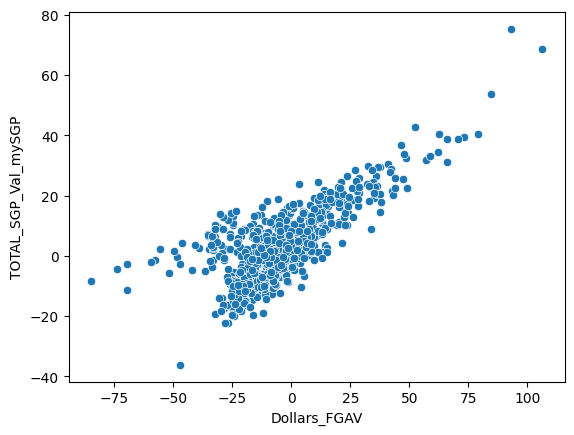

In [42]:
import seaborn as sns
sns.scatterplot(Full_Merge_df,x='Dollars_FGAV',y='TOTAL_SGP_Val_mySGP')

In [43]:
Full_Merge_df['Ottoneu ID']

0        4970
1        6225
2        6305
3        5098
4        5644
        ...  
1340    45769
1341    23326
1342    23541
1343    32184
1344    33058
Name: Ottoneu ID, Length: 1345, dtype: str

In [44]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


In [45]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


# Vibbot ATC

In [46]:
Vibbot_ATC_df = pd.read_csv(League_Proj_files['Vibbot'])
Vibbot_ATC_df.rename(columns={'otto':'Ottoneu ID','$':'Dollars_Vibbot'},inplace=True)

In [47]:
Vibbot_ATC_df.dropna(subset=['Ottoneu ID'],inplace=True)

In [48]:
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].astype(str)
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].str.replace('.0','')

In [49]:
Vibbot_ATC_df.head()

,Ottoneu ID,Name,Team,Pos,Dollars_Vibbot
0,33600,Shohei Ohtani,LAD,Util,80.4
1,18312,Aaron Judge,NYY,OF,68.9
2,23717,Juan Soto,NYM,OF,56.8
3,43894,Paul Skenes,PIT,SP,54.8
4,35204,Tarik Skubal,DET,SP,54.2


In [50]:
Vibbot_ATC_df = Vibbot_ATC_df[['Ottoneu ID','Dollars_Vibbot']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [51]:
Vibbot_ATC_df.columns

Index(['Ottoneu ID', 'Dollars_Vibbot', 'FG ID', 'Ottoneu Positions', 'Name'], dtype='str')

In [52]:
Vibbot_ATC_df.head()

,Ottoneu ID,Dollars_Vibbot,FG ID,Ottoneu Positions,Name
0,33600,80.4,19755,Util/SP,Shohei Ohtani
1,18312,68.9,15640,OF,Aaron Judge
2,23717,56.8,20123,OF,Juan Soto
3,43894,54.8,33677,SP,Paul Skenes
4,35204,54.2,22267,SP,Tarik Skubal


In [53]:
Full_Merge_df = Full_Merge_df.merge(Vibbot_ATC_df,how='outer')

In [54]:
Full_Merge_df.shape

(1346, 92)

In [55]:
Full_Merge_df.head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot
0,10061,NYM,60.70,NaN,NaN,50.97,NaN,NaN,NaN,7.45,...,-9.29,4.12,-4.17,Brooks Raley,548384.0,62.0,-3.32,-4.81,-4.35,NaN
1,10078,CHC,65.71,NaN,NaN,54.64,NaN,NaN,NaN,7.95,...,-5.10,4.12,0.01,Caleb Thielbar,573204.0,66.0,-1.81,-2.20,-3.39,NaN
2,10155,LAA,129.14,556.38,472.47,113.94,65.56,19.01,1.92,27.45,...,-6.75,19.40,13.65,Mike Trout,545361.0,NaN,NaN,NaN,NaN,20.6
3,10231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-45.44,19.18,-25.26,Jose Iglesias,578428.0,NaN,NaN,NaN,NaN,NaN
4,10233,BOS,61.24,NaN,NaN,43.45,NaN,NaN,NaN,5.72,...,9.66,4.12,14.77,Aroldis Chapman,547973.0,62.0,5.79,0.79,-1.64,9.7


In [56]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


In [57]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


<Axes: xlabel='Dollars_Vibbot', ylabel='TOTAL_SGP_Val_mySGP'>

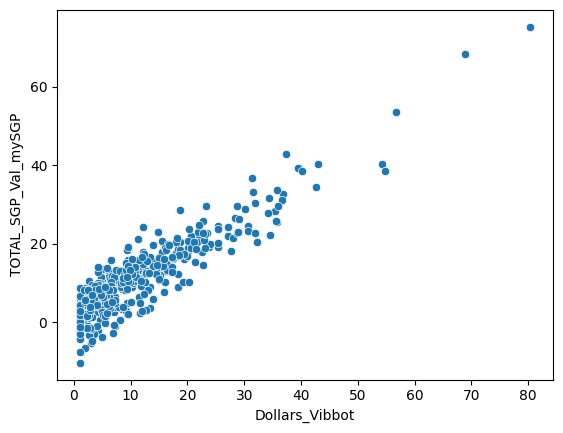

In [58]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Dollars_Vibbot', ylabel='Dollars_FGAV'>

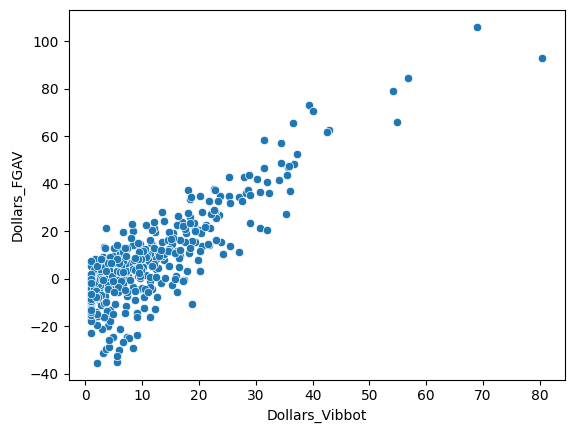

In [59]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='Dollars_FGAV')

# Ottoneu 4x4

In [60]:
Ottoneu_Average_df = pd.read_csv(League_Proj_files['Ottoneu']).drop(columns='Unnamed: 0')

In [61]:
for col in ['Avg Salary','Median Salary','Min Salary','Max Salary','Last 10']:
    Ottoneu_Average_df[col] = Ottoneu_Average_df[col].str.strip('$').astype(float)

In [62]:
Ottoneu_Average_df = Ottoneu_Average_df.rename(
        columns={
            'OttoneuID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions',
            'Avg Salary':'Ottoneu_Avg',
            'Median Salary':'Ottoneu_Med',
            'Min Salary':'Ottoneu_Min',
            'Max Salary':'Ottoneu_Max',
            'Last 10':'Ottoneu_L10',
        }
    )

In [63]:
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].astype(str)
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].str.replace('.0','')

In [64]:
Ottoneu_Average_df = Ottoneu_Average_df[[
    'Ottoneu ID',
    'Ottoneu_Avg',
    'Ottoneu_Med',
    'Ottoneu_Min',
    'Ottoneu_Max',
    'Ottoneu_L10',
    'Roster%'
]].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [65]:
Ottoneu_Average_df.shape

(871, 10)

In [66]:
Ottoneu_Average_df.head()

,Ottoneu ID,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,FG ID,Ottoneu Positions,Name
0,33600,77.33,77.5,60.0,89.0,61.0,100.00,19755,Util/SP,Shohei Ohtani
1,18312,71.50,71.0,54.0,85.0,49.9,100.00,15640,OF,Aaron Judge
2,23717,69.48,70.0,59.0,81.0,69.9,95.83,20123,OF,Juan Soto
3,18276,57.31,60.5,33.0,68.0,49.5,66.67,13611,SS,Mookie Betts
4,23795,52.00,51.0,25.0,68.0,42.1,83.33,19556,OF,Yordan Alvarez


In [67]:
Ottoneu_Average_df.columns

Index(['Ottoneu ID', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'FG ID', 'Ottoneu Positions',
       'Name'],
      dtype='str')

In [68]:
Full_Merge_df = Full_Merge_df.merge(Ottoneu_Average_df,how='outer')

<Axes: xlabel='Ottoneu_Avg', ylabel='TOTAL_SGP_Val_mySGP'>

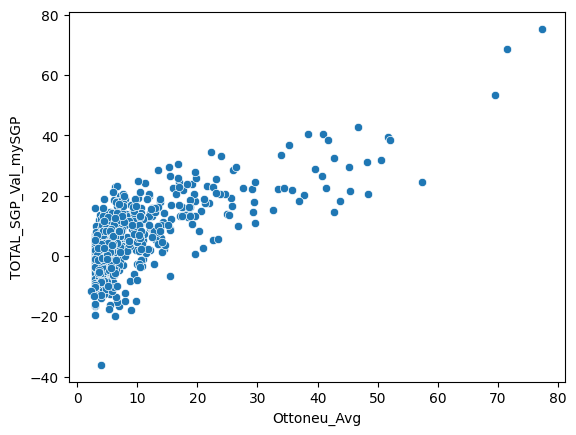

In [69]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_FGAV'>

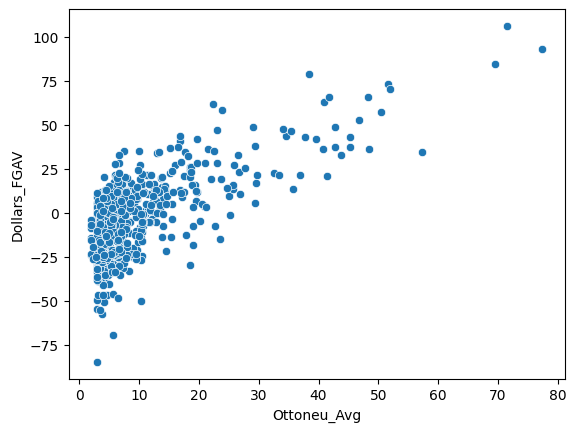

In [70]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_FGAV')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_Vibbot'>

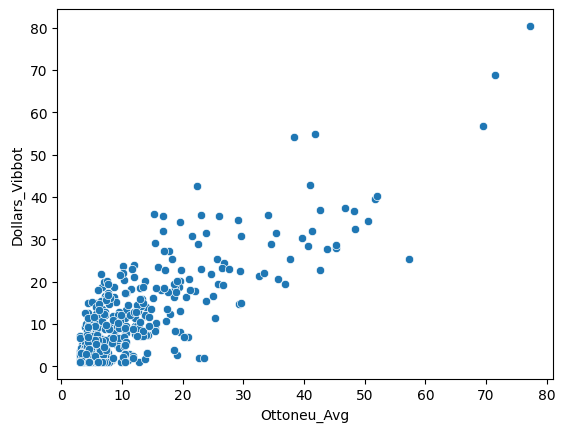

In [71]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_Vibbot')

In [72]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


In [73]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


# League Rosters

In [74]:
League_Rosters_df = pd.read_csv(League_Proj_files['Rosters']).drop(columns='Unnamed: 0')


In [75]:
League_Rosters_df.head()

,TeamID,Team Name,ottoneu ID,FG MajorLeagueID,FG MinorLeagueID,Name,MLB Team,Position(s),Salary
0,55,Jack Klugman's Second Best Lung,39108,28163.0,sa3015532,Junior Caminero,TBR,3B,34
1,55,Jack Klugman's Second Best Lung,23767,19612.0,sa917949,Bo Bichette,NYM,SS,23
2,55,Jack Klugman's Second Best Lung,37094,27676.0,sa1115762,Vinnie Pasquantino,KCR,1B,17
3,55,Jack Klugman's Second Best Lung,36030,26517.0,sa3008745,Noelvi Marte,CIN,3B/OF,14
4,55,Jack Klugman's Second Best Lung,36922,25768.0,sa3010152,CJ Abrams,WSN,SS,14


In [76]:
League_Rosters_df = League_Rosters_df.rename(
        columns={
            'ottoneu ID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions'
        }
    )

In [77]:
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].astype(str)
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].str.replace('.0','')

In [78]:
League_Rosters_df = League_Rosters_df[['TeamID','Team Name','Ottoneu ID','Salary']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [79]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP', 'R_mySGP', 'RBI_mySGP',
       'BB_mySGP', 'HBP_mySGP', 'SF_mySGP', 'WAR_mySGP', 'ADP_mySGP',
       'POS_mySGP', 'Ottoneu ID', 'Ottoneu Positions', 'Name', 'OBP_mySGP',
       'TB_mySGP', 'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP',
       'HR_SGP_raw_mySGP', 'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP',
       'TOTAL_SGP_raw_mySGP', 'R_SGP_repl_mySGP', 'Repl_Pos_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_repl_mySGP', 'HR_SGP_norm_mySGP',
       'OBP_SGP_repl_mySGP', 'OBP_SGP_norm_mySGP', 'SLG_SGP_repl_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'W_mySGP', 'L_mySGP',
       'QS_mySGP', 'GS_mySGP', 'SV_mySGP', 'HLD_mySGP', 'IP_mySGP',
       'TBF_mySGP', 'ER_mySGP', 'SO_mySGP', 'HR9_mySGP', 'ERA_mySGP',
      

In [80]:
League_Rosters_df.columns

Index(['TeamID', 'Team Name', 'Ottoneu ID', 'Salary', 'FG ID',
       'Ottoneu Positions', 'Name'],
      dtype='str')

In [81]:
League_Rosters_df[League_Rosters_df['TeamID'] == 240]

,TeamID,Team Name,Ottoneu ID,Salary,FG ID,Ottoneu Positions,Name
171,240,Largely Indistinguishables,43894,41,33677,SP,Paul Skenes
172,240,Largely Indistinguishables,18347,39,16478,OF,Kyle Schwarber
173,240,Largely Indistinguishables,35204,25,22267,SP,Tarik Skubal
174,240,Largely Indistinguishables,36671,24,25436,SP,George Kirby
175,240,Largely Indistinguishables,33682,20,22250,SP,Logan Gilbert
176,240,Largely Indistinguishables,19168,16,18679,SP,Freddy Peralta
177,240,Largely Indistinguishables,43896,15,33333,OF,Wyatt Langford
178,240,Largely Indistinguishables,38398,13,27815,2B/3B,Jordan Westburg
179,240,Largely Indistinguishables,23831,12,20036,3B,Isaac Paredes
180,240,Largely Indistinguishables,20975,11,20778,SP,Cristopher Sanchez


In [82]:
Full_Merge_df = Full_Merge_df.merge(League_Rosters_df,how='outer')

In [83]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [84]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


# Total Value Replacement Level

In [85]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [86]:
Full_Merge_df[['FG ID',    'Name',
    'Team',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary']].sort_values(by=['ADP_FGAV']).tail(150)

,FG ID,Name,Team,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
436,19779,Dairon Blanco,NaN,OF,33735,999.0,NaN,-25.05,NaN,NaN,NaN,NaN,NaN,NaN
438,19802,Jhonny Pereda,NaN,C,18764,999.0,NaN,-15.74,NaN,NaN,NaN,NaN,NaN,NaN
441,19813,Charles Leblanc,NaN,Util,31435,999.0,NaN,-27.06,NaN,NaN,NaN,NaN,NaN,NaN
442,19818,Joshua Palacios,NaN,OF,31535,999.0,NaN,-25.48,NaN,NaN,NaN,NaN,NaN,NaN
443,19844,Abraham Toro,NaN,1B/3B,32630,999.0,NaN,-31.17,NaN,3.33,3.0,3.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,sa3067675,Josuar Gonzalez,NaN,SS,46099,NaN,NaN,NaN,NaN,2.00,2.0,2.0,2.0,NaN
1455,sa3069100,Ethan Holliday,NaN,Util,47552,NaN,NaN,NaN,NaN,5.87,5.0,2.0,13.0,NaN
1456,sa3069164,Eli Willits,NaN,Util,47549,NaN,NaN,NaN,NaN,3.67,3.5,3.0,5.0,NaN
1461,NaN,JoJo Parker,NaN,Util,47541,NaN,NaN,NaN,NaN,3.00,3.0,3.0,3.0,NaN


In [87]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [88]:
Full_Merge_df[Full_Merge_df['Name'].isna()][['FG ID','Ottoneu ID','Name']]

,FG ID,Ottoneu ID,Name


In [89]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [90]:
Full_Merge_sorted_df = Full_Merge_df[[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]].sort_values(by=['ADP_FGAV'])

In [91]:
Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == 240]

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
644,Tarik Skubal,DET,240.0,Largely Indistinguishables,SP,35204,6.11,40.44,78.97,54.2,38.42,40.5,15.0,54.0,25.0
1210,Paul Skenes,PIT,240.0,Largely Indistinguishables,SP,43894,9.47,38.63,65.84,54.8,41.75,41.0,14.0,60.0,41.0
219,Kyle Schwarber,PHI,240.0,Largely Indistinguishables,OF,18347,25.08,40.40,62.65,42.9,40.96,39.0,25.0,56.0,39.0
541,Cristopher Sanchez,PHI,240.0,Largely Indistinguishables,SP,20975,27.17,29.65,36.82,36.0,15.25,15.5,8.0,24.0,11.0
547,Jhoan Duran,PHI,240.0,Largely Indistinguishables,RP,22559,33.97,24.36,21.16,12.1,11.29,11.0,8.0,15.0,10.0
640,Logan Gilbert,SEA,240.0,Largely Indistinguishables,SP,33682,37.75,22.97,35.21,28.9,22.58,21.0,15.0,35.0,20.0
1199,Wyatt Langford,TEX,240.0,Largely Indistinguishables,OF,43896,49.64,22.77,28.79,22.7,17.00,17.5,6.0,28.0,15.0
344,Freddy Peralta,NYM,240.0,Largely Indistinguishables,SP,19168,62.33,17.64,3.34,17.9,21.26,20.0,14.0,34.0,16.0
793,George Kirby,SEA,240.0,Largely Indistinguishables,SP,36671,64.19,20.99,28.41,22.9,23.09,24.0,10.0,40.0,24.0
631,Brice Turang,MIL,240.0,Largely Indistinguishables,2B,33634,68.44,2.96,4.96,9.2,6.71,6.5,3.0,14.0,7.0


In [92]:
# sns.pairplot(Full_Merge_sorted_df[ \
#     (Full_Merge_sorted_df['ADP_FGAV'] <= 500) | \
#     (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
#     (Full_Merge_sorted_df['Salary'] > 0.)][[
#     'Name',
#     'Team',
#     'Ottoneu Positions',
#     'ADP_FGAV',
#     'TOTAL_SGP_Val_mySGP',
#     'Dollars_FGAV',
#     'Dollars_Vibbot',
#     'Ottoneu_Avg',
#     'Ottoneu_Med', 
#     'Ottoneu_Min', 
#     'Ottoneu_Max',
#     'Salary'
# ]])

In [93]:
Full_Merge_sorted_df

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
434,Shohei Ohtani,LAD,154.0,The Rime of Jamie Moyer,Util/SP,33600,1.11,75.35,92.96,80.4,77.33,77.5,60.0,89.0,75.0
182,Aaron Judge,NYY,197.0,St. CGT VI,OF,18312,1.97,68.53,106.14,68.9,71.50,71.0,54.0,85.0,73.0
821,Bobby Witt Jr.,KCR,236.0,Yoshi Teddy Bear,SS,36668,3.28,42.90,52.55,37.3,46.71,46.5,24.0,68.0,48.0
491,Juan Soto,NYM,197.0,St. CGT VI,OF,23717,4.47,53.55,84.64,56.8,69.48,70.0,59.0,81.0,64.0
93,José Ramírez,CLE,112.0,Hornswogglers,3B,18284,5.31,20.52,36.09,32.3,48.45,47.0,38.0,60.0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,Josuar Gonzalez,NaN,NaN,NaN,SS,46099,NaN,NaN,NaN,NaN,2.00,2.0,2.0,2.0,NaN
1455,Ethan Holliday,NaN,NaN,NaN,Util,47552,NaN,NaN,NaN,NaN,5.87,5.0,2.0,13.0,NaN
1456,Eli Willits,NaN,NaN,NaN,Util,47549,NaN,NaN,NaN,NaN,3.67,3.5,3.0,5.0,NaN
1461,JoJo Parker,NaN,NaN,NaN,Util,47541,NaN,NaN,NaN,NaN,3.00,3.0,3.0,3.0,NaN


In [94]:
quick_plot = Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['ADP_FGAV'] <= 50) ]#| \
    # (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    # (Full_Merge_sorted_df['Salary'] > 0.)]

In [95]:
def quick_plotting_fn(quick_plot,ax1):
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    ax1.tick_params(axis='y', which='major', labelsize=7)
    return

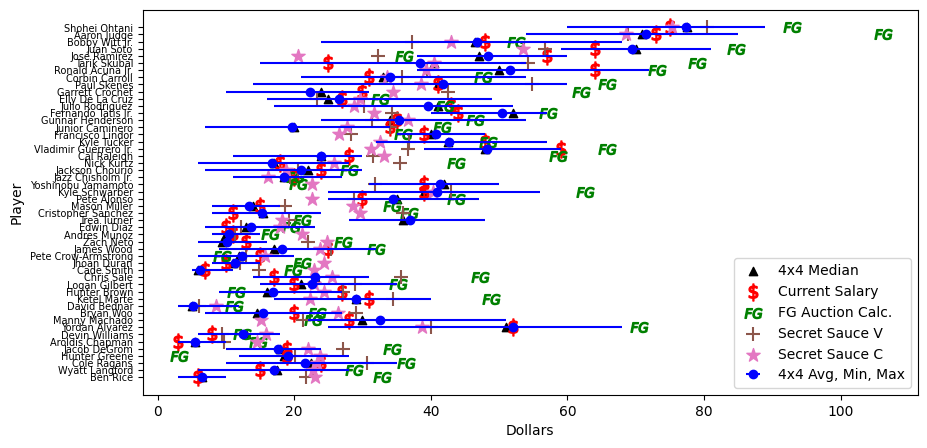

In [96]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
quick_plotting_fn(quick_plot,ax1)
plt.show()

In [97]:
Full_Merge_sorted_df.columns

Index(['Name', 'Team', 'TeamID', 'Team Name', 'Ottoneu Positions',
       'Ottoneu ID', 'ADP_FGAV', 'TOTAL_SGP_Val_mySGP', 'Dollars_FGAV',
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Salary'],
      dtype='str')

In [98]:
Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(['SP','RP','SP/RP','Util/SP'])]['ADP_FGAV'].rank()

434     1.0
644     2.0
1210    3.0
908     4.0
1215    5.0
       ... 
1435    NaN
1441    NaN
1443    NaN
1446    NaN
1453    NaN
Name: ADP_FGAV, Length: 662, dtype: float64

In [99]:
Hitter_Pitcher_Repl_SGP_df.columns

Index(['Ottoneu Positions', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'AB_mySGP',
       'ADP_mySGP', 'BB_mySGP', 'G_mySGP', 'H_mySGP', 'HBP_mySGP', 'HR_mySGP',
       'PA_mySGP', 'R_mySGP', 'RBI_mySGP', 'SF_mySGP', 'WAR_mySGP',
       'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP', 'OBP_mySGP', 'OBP_SGP_raw_mySGP',
       'SLG_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP', 'ER_mySGP',
       'GS_mySGP', 'HLD_mySGP', 'IP_mySGP', 'L_mySGP', 'QS_mySGP', 'SO_mySGP',
       'SV_mySGP', 'TBF_mySGP', 'W_mySGP', 'SO_SGP_raw_mySGP', 'HR9_mySGP',
       'HR9_SGP_raw_mySGP', 'ERA_mySGP', 'ERA_SGP_raw_mySGP', 'WHIP_mySGP',
       'WHIP_SGP_raw_mySGP'],
      dtype='str')

In [100]:
pd.DataFrame(Hitter_Pitcher_Repl_SGP_df.loc[Hitter_Pitcher_Repl_SGP_df[Hitter_Pitcher_Repl_SGP_df['Ottoneu Positions'].isin(['2B','SS'])]['TOTAL_SGP_raw_mySGP'].idxmin()]).T.reset_index(drop=True)

,Ottoneu Positions,1B_mySGP,2B_mySGP,3B_mySGP,AB_mySGP,ADP_mySGP,BB_mySGP,G_mySGP,H_mySGP,HBP_mySGP,...,SV_mySGP,TBF_mySGP,W_mySGP,SO_SGP_raw_mySGP,HR9_mySGP,HR9_SGP_raw_mySGP,ERA_mySGP,ERA_SGP_raw_mySGP,WHIP_mySGP,WHIP_SGP_raw_mySGP
0,SS,52.49,16.08,2.06,333.37,549.28,33.02,88.75,79.73,3.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###################################
Position C Replacement Level = 24
###################################
Replacement Level ADP_FGAV C 284.10 +- 34.64


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank
305,Tyler Stephenson,CIN,NaN,NaN,C,22654,247.28,5.57,1.10,1.7,8.33,7.0,4.0,14.0,NaN,22.0
751,Ryan Jeffers,MIN,NaN,NaN,C,33652,249.31,9.23,14.14,5.5,4.93,5.0,3.0,11.0,NaN,23.0
429,Carlos Narvaez,BOS,NaN,NaN,C,32084,289.33,-1.33,-1.50,NaN,3.83,3.0,3.0,6.0,NaN,24.0
102,Carson Kelly,CHC,NaN,NaN,C,23714,315.78,-0.46,-0.41,NaN,4.08,3.0,3.0,8.0,NaN,25.0
994,Edgar Quero,CHW,NaN,NaN,C,38887,318.78,0.99,0.21,NaN,3.33,3.0,3.0,4.0,NaN,26.0


Replacement Level TOTAL_SGP_Val_mySGP C 3.07 +- 0.99


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank,TOTAL_SGP_Val_mySGP_C_rank
909,Dillon Dingler,DET,NaN,NaN,C,38308,219.64,1.61,-2.52,NaN,3.73,4.0,3.0,6.0,NaN,19.0,26.0
383,Sean Murphy,ATL,185.0,Chili Dog MVP,C,31687,399.56,2.87,1.00,1.0,6.79,7.0,3.0,13.0,4.0,32.0,25.0
1006,Carter Jensen,KCR,NaN,NaN,C,40505,999.00,2.99,1.72,NaN,5.33,5.0,3.0,9.0,NaN,68.0,24.0
613,Bo Naylor,CLE,NaN,NaN,C,33676,329.97,3.59,5.39,1.0,3.00,3.0,3.0,3.0,NaN,27.0,23.0
1204,Kyle Teel,CHW,241.0,🦫 Beavers in Scoring Position!,C,43949,181.47,4.30,6.45,4.0,4.63,4.5,3.0,8.0,4.0,17.0,22.0


Replacement Level Dollars_FGAV C 0.99 +- 0.54


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank,TOTAL_SGP_Val_mySGP_C_rank,Dollars_FGAV_C_rank
994,Edgar Quero,CHW,NaN,NaN,C,38887,318.78,0.99,0.21,NaN,3.33,3.0,3.0,4.0,NaN,26.0,28.0,26.0
225,Danny Jansen,TEX,NaN,NaN,C,19481,446.00,-1.04,0.94,NaN,11.00,11.0,11.0,11.0,NaN,35.0,31.0,25.0
383,Sean Murphy,ATL,185.0,Chili Dog MVP,C,31687,399.56,2.87,1.00,1.0,6.79,7.0,3.0,13.0,4.0,32.0,25.0,24.0
305,Tyler Stephenson,CIN,NaN,NaN,C,22654,247.28,5.57,1.10,1.7,8.33,7.0,4.0,14.0,NaN,22.0,19.0,23.0
1006,Carter Jensen,KCR,NaN,NaN,C,40505,999.00,2.99,1.72,NaN,5.33,5.0,3.0,9.0,NaN,68.0,24.0,22.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


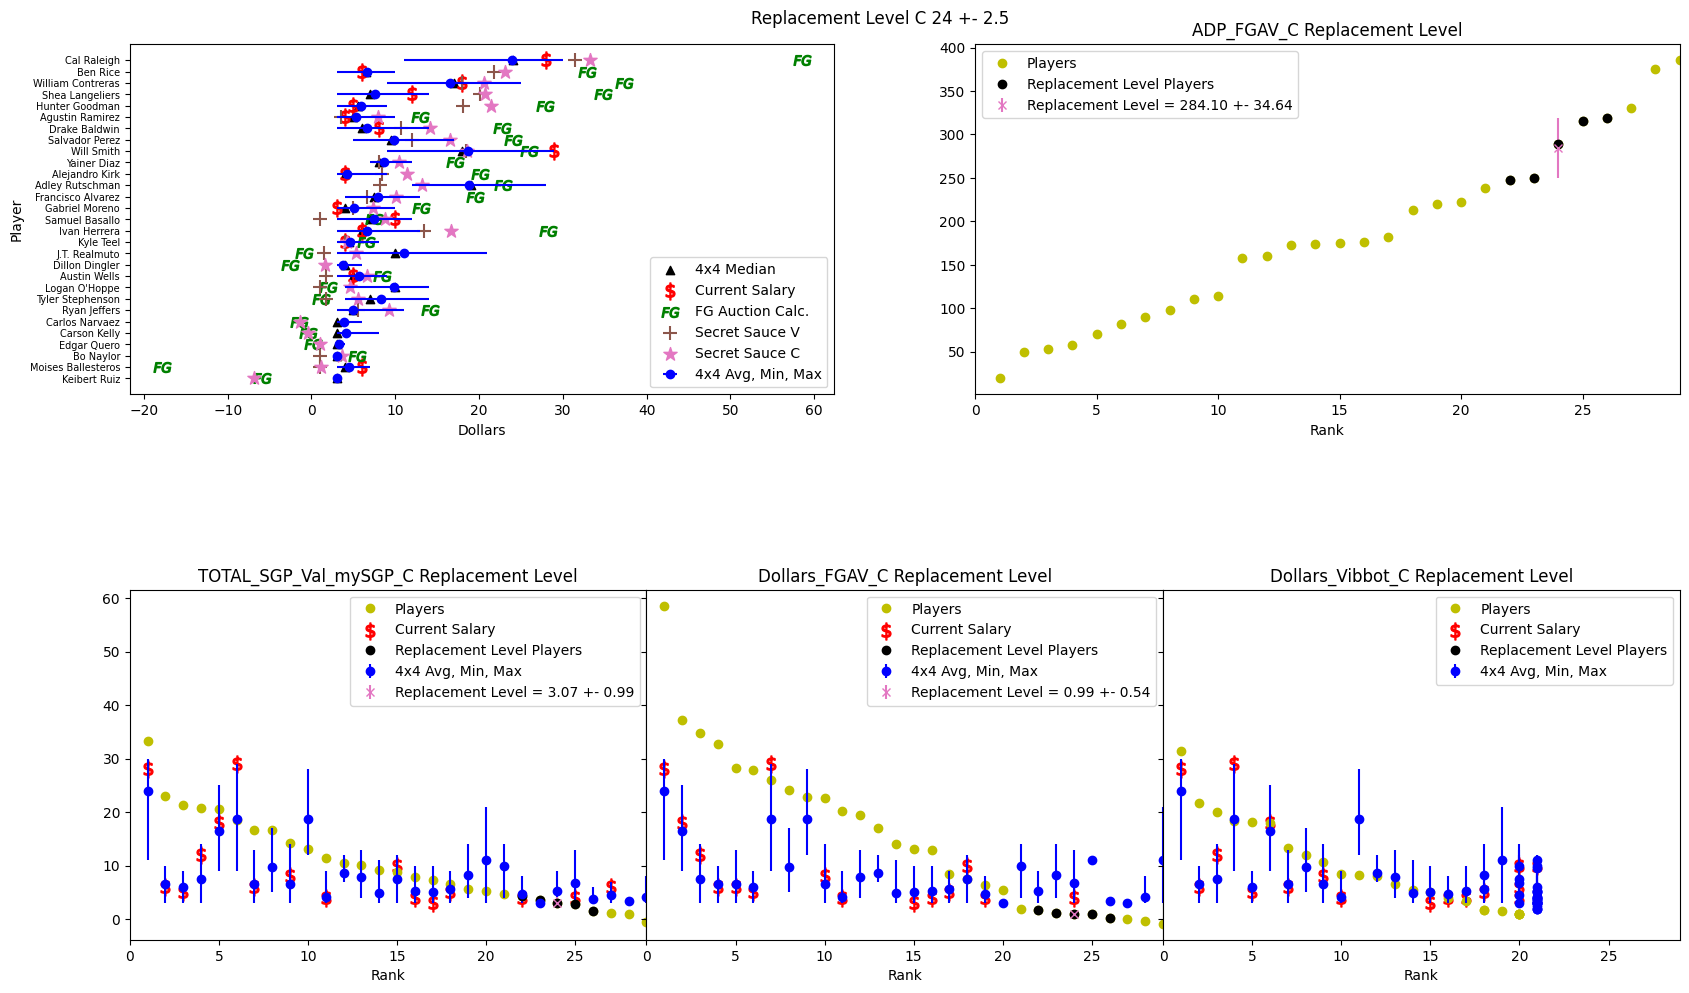

###################################
Position 1B Replacement Level = 25
###################################
Replacement Level ADP_FGAV 1B 263.90 +- 16.20


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank
1044,Kyle Manzardo,CLE,247.0,Roberto Big Piece and the 69ers,1B,40508,238.19,2.93,6.00,12.0,7.21,7.0,4.0,11.0,6.0,23.0
879,Spencer Steer,CIN,NaN,NaN,1B/OF,37216,257.69,8.41,11.14,9.4,10.69,10.5,6.0,20.0,NaN,24.0
217,Ryan O'Hearn,PIT,240.0,Largely Indistinguishables,1B/OF,21156,272.83,8.25,4.71,9.1,5.57,5.0,3.0,10.0,5.0,25.0
590,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,273.61,3.96,-0.58,7.9,10.73,11.0,3.0,15.0,NaN,26.0
646,Jake Burger,TEX,NaN,NaN,1B,23809,277.17,3.63,5.26,6.3,8.36,7.0,3.0,19.0,NaN,27.0


Replacement Level TOTAL_SGP_Val_mySGP 1B 3.96 +- 0.47


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank
886,Josh Smith,TEX,NaN,NaN,1B/SS/3B/OF,37960,353.39,3.62,-9.92,1.0,4.87,5.0,3.0,7.0,NaN,36.0,27.0
646,Jake Burger,TEX,NaN,NaN,1B,23809,277.17,3.63,5.26,6.3,8.36,7.0,3.0,19.0,NaN,27.0,26.0
987,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,308.17,3.82,8.05,8.6,8.63,8.0,6.0,12.0,12.0,34.0,25.0
590,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,273.61,3.96,-0.58,7.9,10.73,11.0,3.0,15.0,NaN,26.0,24.0
1133,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,214.69,4.77,5.12,11.7,5.38,4.5,3.0,13.0,13.0,21.0,23.0


Replacement Level Dollars_FGAV 1B 5.71 +- 0.65


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank,Dollars_FGAV_1B_rank
1133,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,214.69,4.77,5.12,11.7,5.38,4.5,3.0,13.0,13.0,21.0,23.0,27.0
646,Jake Burger,TEX,NaN,NaN,1B,23809,277.17,3.63,5.26,6.3,8.36,7.0,3.0,19.0,NaN,27.0,26.0,26.0
88,Christian Walker,HOU,NaN,NaN,1B,18389,191.50,2.02,5.44,9.4,12.14,11.0,7.0,18.0,NaN,18.0,33.0,25.0
1044,Kyle Manzardo,CLE,247.0,Roberto Big Piece and the 69ers,1B,40508,238.19,2.93,6.00,12.0,7.21,7.0,4.0,11.0,6.0,23.0,29.0,24.0
1226,Jac Caglianone,KCR,241.0,🦫 Beavers in Scoring Position!,1B/OF,45720,227.89,8.36,6.70,4.5,7.00,7.0,3.0,11.0,10.0,22.0,18.0,23.0


Replacement Level Dollars_Vibbot 1B 7.40 +- 0.88


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank,Dollars_FGAV_1B_rank,Dollars_Vibbot_1B_rank
646,Jake Burger,TEX,NaN,NaN,1B,23809,277.17,3.63,5.26,6.3,8.36,7.0,3.0,19.0,NaN,27.0,26.0,26.0,27.0
1190,Nolan Schanuel,LAA,90.0,Carlos Pérez's K-Dance,1B,43932,303.64,-0.65,12.91,7.0,4.44,4.0,3.0,8.0,6.0,33.0,36.0,16.0,26.0
78,Josh Bell,MIN,NaN,NaN,1B,18152,334.39,-1.01,3.82,7.2,3.00,3.0,3.0,3.0,NaN,35.0,39.0,29.0,25.0
590,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,273.61,3.96,-0.58,7.9,10.73,11.0,3.0,15.0,NaN,26.0,24.0,33.0,24.0
987,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,308.17,3.82,8.05,8.6,8.63,8.0,6.0,12.0,12.0,34.0,25.0,20.0,23.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


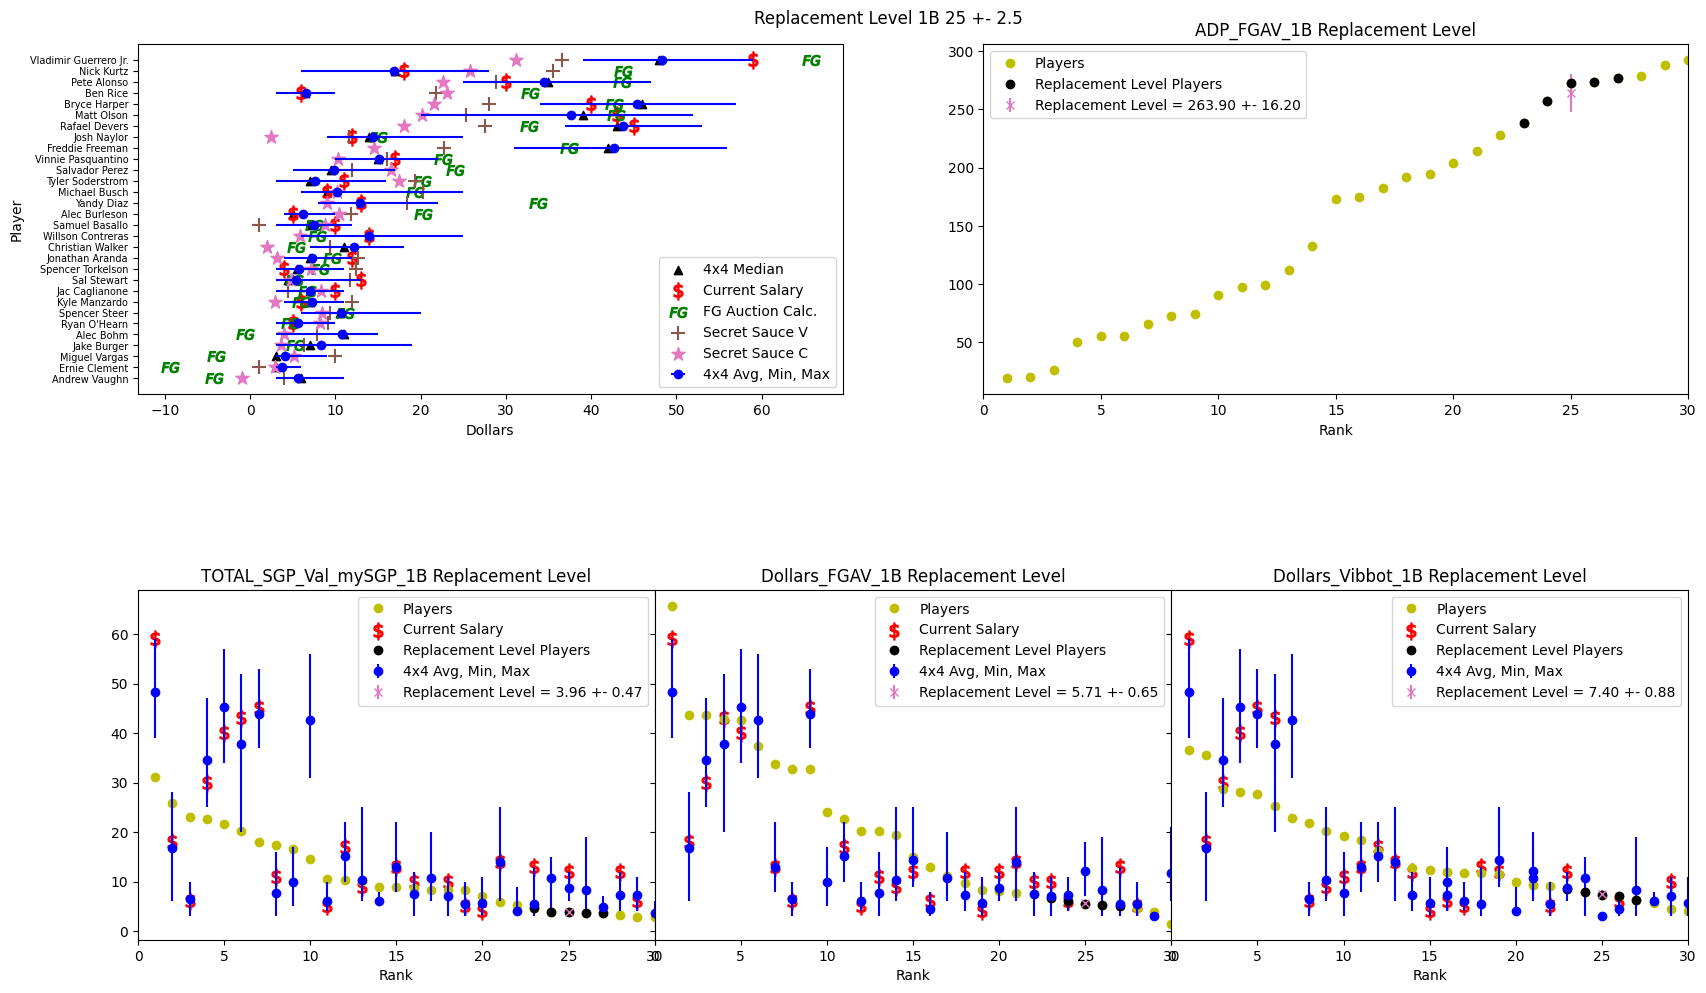

###################################
Position 2B Replacement Level = 27
###################################
Replacement Level ADP_FGAV 2B 291.18 +- 6.94


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank
753,Brendan Donovan,STL,242.0,Smoak and Mirrors,2B/SS/OF,34619,281.33,12.63,9.31,10.7,9.65,10.0,6.0,13.0,10.0,25.0
508,Ernie Clement,TOR,NaN,NaN,1B/2B/SS/3B,31958,288.28,2.92,-9.38,1.0,3.71,3.0,3.0,6.0,NaN,26.0
401,Tommy Edman,LAD,90.0,Carlos Pérez's K-Dance,2B/3B/OF,31703,293.06,-1.41,-9.22,1.0,7.08,6.5,3.0,15.0,5.0,27.0
340,Luis Arraez,NaN,NaN,NaN,1B/2B,20545,293.11,NaN,1.48,2.4,11.80,12.0,6.0,21.0,NaN,28.0
680,Lenyn Sosa,CHW,NaN,NaN,1B/2B,26411,300.11,-8.49,-13.25,NaN,4.08,3.0,3.0,12.0,NaN,29.0


Replacement Level TOTAL_SGP_Val_mySGP 2B 2.52 +- 0.33


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank
1197,Luke Keaschall,MIN,112.0,Hornswogglers,2B,44057,152.06,2.05,2.54,9.5,5.46,5.0,3.0,11.0,8.0,10.0,29.0
1034,Matt McLain,CIN,NaN,NaN,2B,40371,231.17,2.42,-5.55,5.8,10.69,10.5,6.0,16.0,NaN,18.0,28.0
226,Ozzie Albies,ATL,90.0,Carlos Pérez's K-Dance,2B,18397,182.75,2.50,3.96,7.0,20.92,19.0,9.0,35.0,9.0,13.0,27.0
165,Jeff Mcneil,ATH,197.0,St. CGT VI,2B/OF,18644,351.89,2.70,-1.84,4.2,4.25,3.5,3.0,8.0,3.0,34.0,26.0
825,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,2.92,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,41.0,25.0


Replacement Level Dollars_FGAV 2B -4.82 +- 0.72


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank,Dollars_FGAV_2B_rank
311,Jake Cronenworth,SDP,NaN,NaN,1B/2B/SS,22004,405.86,9.01,-5.64,5.6,6.00,6.0,5.0,8.0,NaN,42.0,9.0,29.0
1034,Matt McLain,CIN,NaN,NaN,2B,40371,231.17,2.42,-5.55,5.8,10.69,10.5,6.0,16.0,NaN,18.0,28.0,28.0
263,Willi Castro,COL,197.0,St. CGT VI,2B/3B/OF,21708,365.00,3.39,-4.53,4.8,6.08,5.0,5.0,11.0,7.0,36.0,22.0,27.0
852,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,253.22,-0.93,-4.26,2.4,4.75,5.0,3.0,8.0,3.0,23.0,38.0,26.0
643,Xavier Edwards,MIA,NaN,NaN,2B/SS,33645,175.72,4.38,-4.12,1.0,6.11,5.0,3.0,12.0,NaN,11.0,19.0,25.0


Replacement Level Dollars_Vibbot 2B 1.39 +- 0.64


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank,Dollars_FGAV_2B_rank,Dollars_Vibbot_2B_rank
643,Xavier Edwards,MIA,NaN,NaN,2B/SS,33645,175.72,4.38,-4.12,1.0,6.11,5.0,3.0,12.0,NaN,11.0,19.0,25.0,29.0
1031,Caleb Durbin,MIL,NaN,NaN,2B/3B,40398,232.00,-3.00,-6.44,1.0,3.30,3.0,3.0,6.0,NaN,19.0,48.0,30.0,29.0
931,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,260.58,-0.10,-12.60,1.0,4.40,3.0,3.0,7.0,NaN,24.0,35.0,42.0,29.0
508,Ernie Clement,TOR,NaN,NaN,1B/2B/SS/3B,31958,288.28,2.92,-9.38,1.0,3.71,3.0,3.0,6.0,NaN,26.0,24.0,38.0,29.0
401,Tommy Edman,LAD,90.0,Carlos Pérez's K-Dance,2B/3B/OF,31703,293.06,-1.41,-9.22,1.0,7.08,6.5,3.0,15.0,5.0,27.0,41.0,36.0,29.0
1142,Chase Meidroth,CHW,NaN,NaN,2B/SS,42304,336.81,4.41,-1.64,1.0,4.44,3.0,3.0,11.0,NaN,33.0,18.0,18.0,29.0
1032,Marcelo Mayer,BOS,90.0,Carlos Pérez's K-Dance,2B/SS/3B,40095,371.67,6.73,-8.45,1.0,7.09,7.0,4.0,11.0,9.0,37.0,12.0,35.0,29.0
825,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,2.92,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,41.0,25.0,45.0,29.0
660,Tyler Freeman,COL,NaN,NaN,2B/OF,26882,428.31,-2.82,-10.24,1.0,4.86,5.0,3.0,7.0,NaN,46.0,47.0,39.0,29.0
941,Casey Schmitt,SFG,NaN,NaN,1B/2B/3B,38383,480.94,-7.60,-16.60,1.0,3.00,3.0,3.0,3.0,NaN,53.0,63.0,52.0,29.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


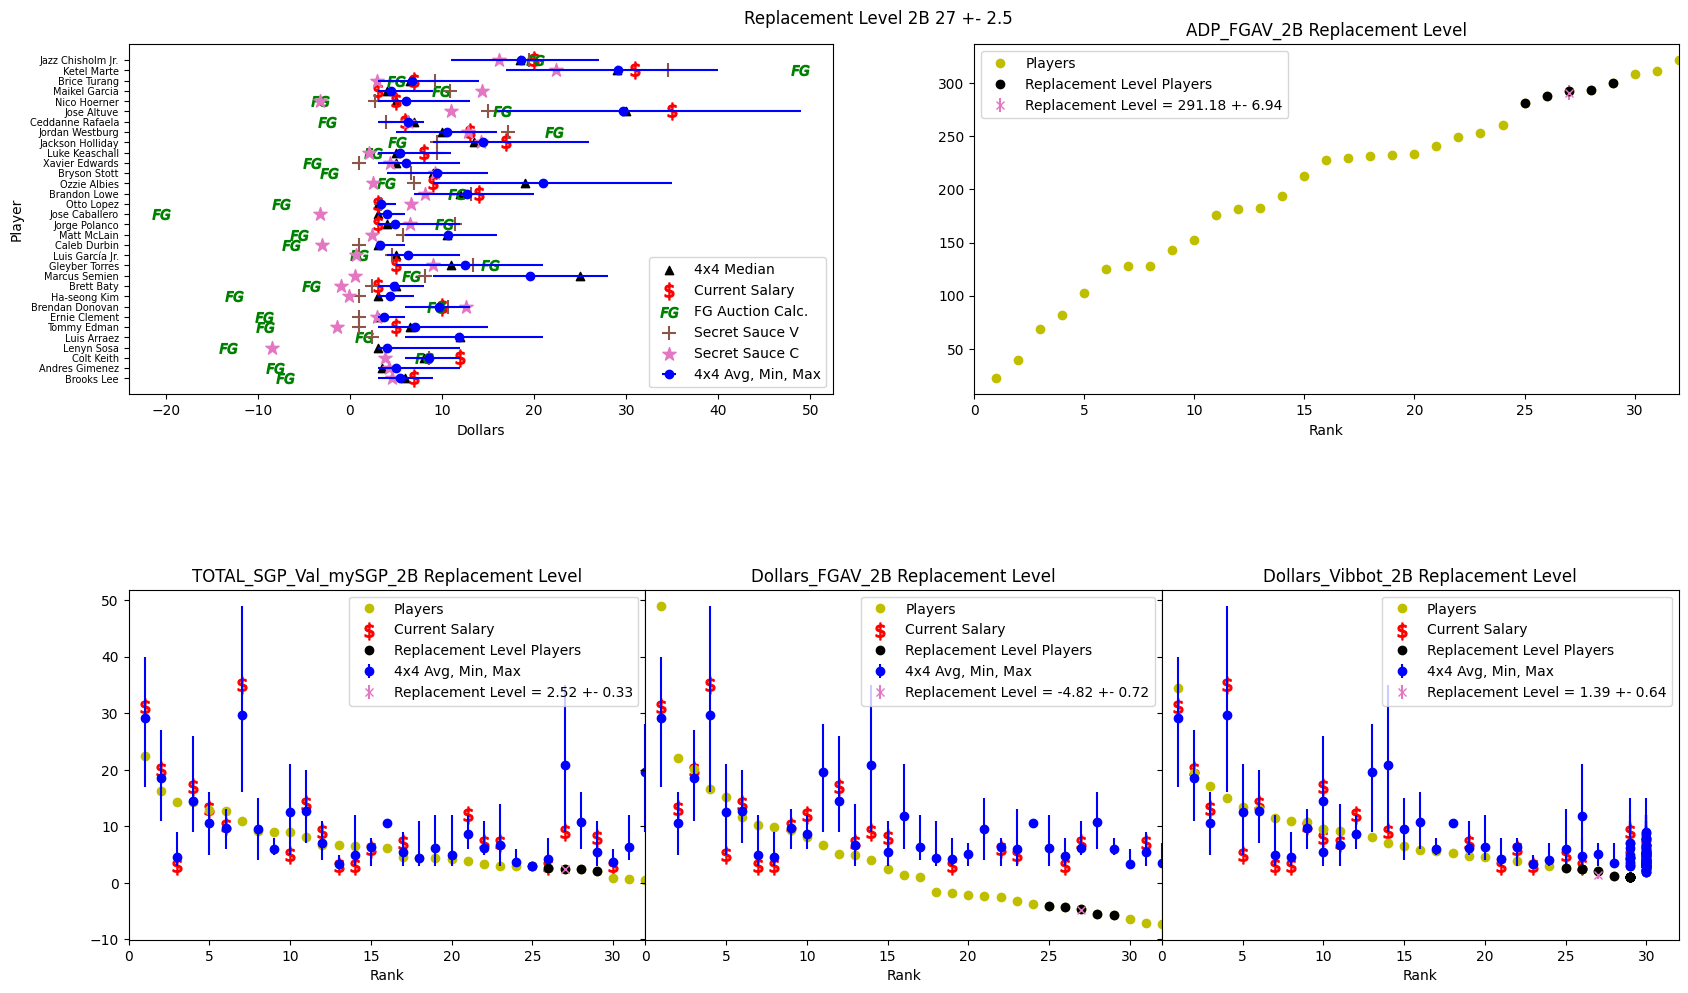

###################################
Position SS Replacement Level = 44
###################################
Replacement Level ADP_FGAV SS 420.20 +- 17.65


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank
825,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,2.92,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,42.0
311,Jake Cronenworth,SDP,NaN,NaN,1B/2B/SS,22004,405.86,9.01,-5.64,5.6,6.00,6.0,5.0,8.0,NaN,43.0
705,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,-0.38,-13.93,NaN,3.00,3.0,3.0,3.0,NaN,44.0
1124,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,435.14,-0.70,-12.56,NaN,NaN,NaN,NaN,NaN,NaN,45.0
1072,Carson Williams,TBR,154.0,The Rime of Jamie Moyer,SS,40266,442.86,2.13,-18.68,NaN,4.65,4.0,3.0,7.0,4.0,46.0


Replacement Level TOTAL_SGP_Val_mySGP SS 0.12 +- 0.47


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank,TOTAL_SGP_Val_mySGP_SS_rank
705,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,-0.38,-13.93,NaN,3.00,3.0,3.0,3.0,NaN,44.0,46.0
931,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,260.58,-0.10,-12.60,1.0,4.40,3.0,3.0,7.0,NaN,26.0,45.0
665,Gabriel Arias,CLE,NaN,NaN,2B/SS,26408,468.25,-0.02,-21.33,NaN,5.00,6.0,3.0,6.0,NaN,47.0,44.0
1427,JJ Wetherholt,STL,197.0,St. CGT VI,2B/SS,45713,999.00,0.22,-11.72,NaN,5.00,4.5,2.0,11.0,6.0,76.0,43.0
922,Nick Gonzales,PIT,241.0,🦫 Beavers in Scoring Position!,2B/SS,38314,523.72,0.87,-12.70,NaN,3.71,3.0,3.0,6.0,3.0,53.0,42.0


Replacement Level Dollars_FGAV SS -14.21 +- 1.37


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank,TOTAL_SGP_Val_mySGP_SS_rank,Dollars_FGAV_SS_rank
1041,Max Muncy,ATH,NaN,NaN,2B/SS/3B,40460,495.72,-1.52,-16.53,NaN,5.00,5.0,3.0,7.0,NaN,51.0,49.0,46.0
1405,Kevin McGonigle,DET,241.0,🦫 Beavers in Scoring Position!,SS,44223,999.00,-1.21,-14.09,1.0,4.42,4.0,2.0,8.0,2.0,76.0,48.0,45.0
705,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,-0.38,-13.93,NaN,3.00,3.0,3.0,3.0,NaN,44.0,46.0,44.0
825,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,2.92,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,42.0,38.0,43.0
1451,Konnor Griffin,PIT,241.0,🦫 Beavers in Scoring Position!,SS,45769,999.00,2.76,-13.02,1.0,4.50,4.5,2.0,12.0,7.0,76.0,39.0,42.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


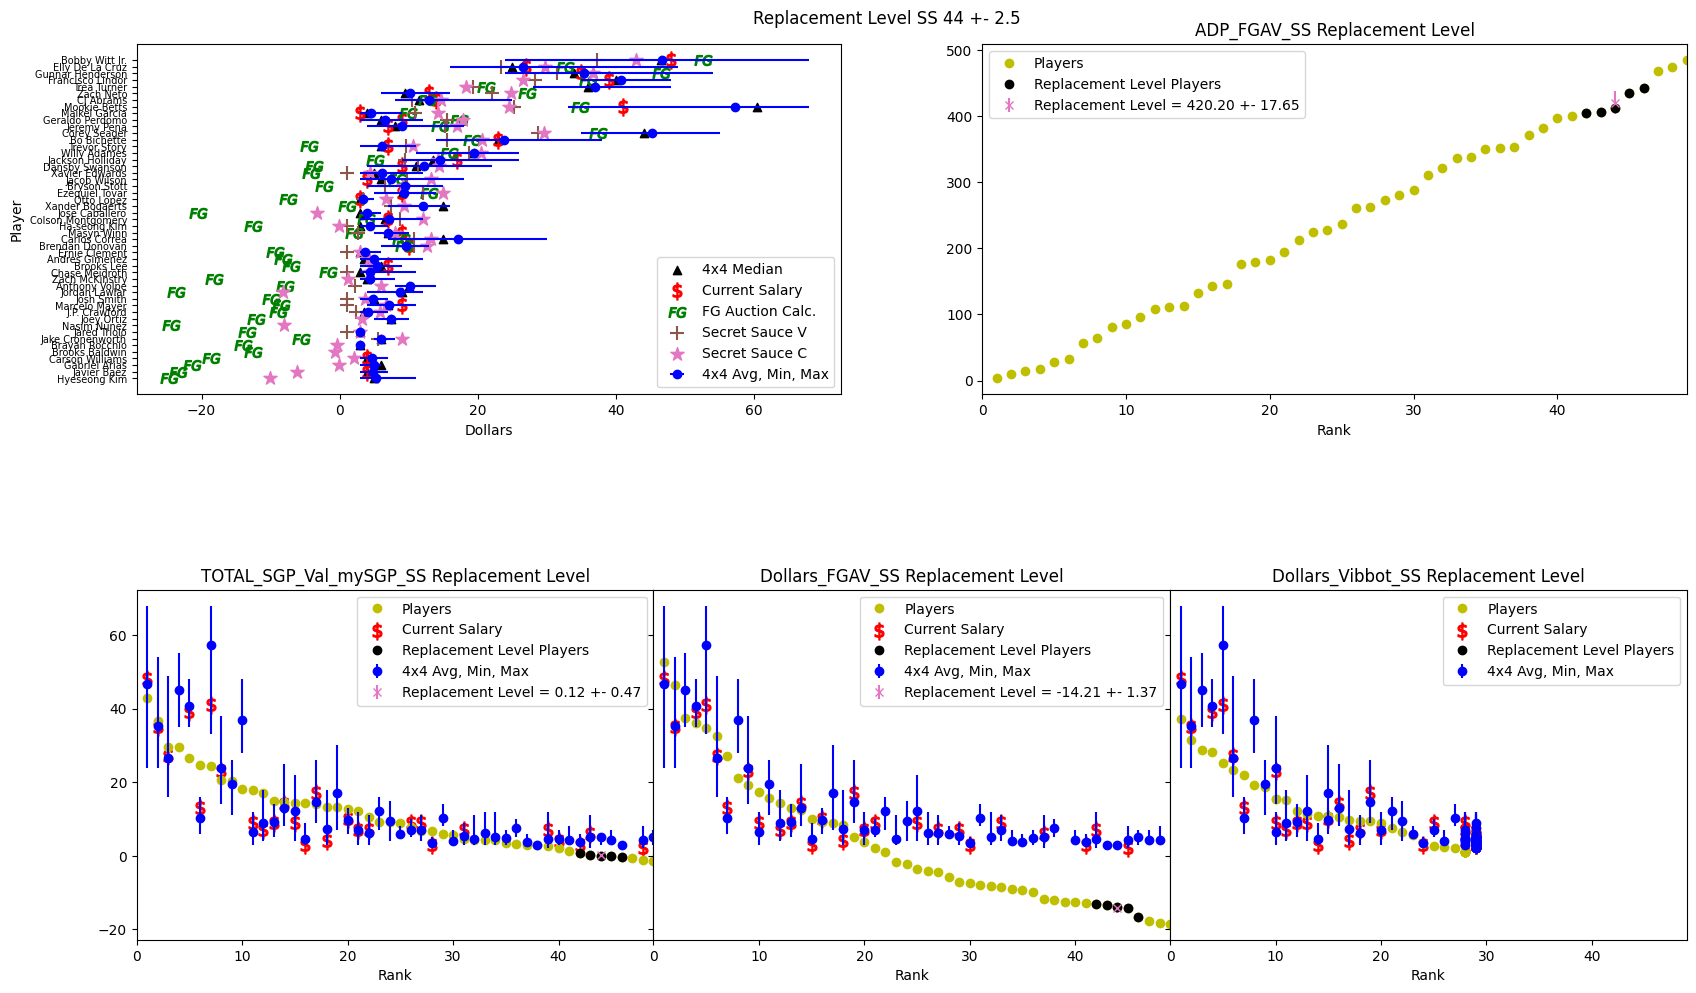

###################################
Position 3B Replacement Level = 19
###################################
Replacement Level ADP_FGAV 3B 235.66 +- 10.34


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank
696,Jose Caballero,NYY,NaN,NaN,2B/SS/3B/OF,26915,227.44,-3.26,-20.55,NaN,4.00,3.0,3.0,6.0,NaN,17.0
79,Jorge Polanco,NYM,185.0,Chili Dog MVP,2B/3B,13217,229.47,6.48,10.25,11.4,4.87,4.0,3.0,12.0,3.0,18.0
1031,Caleb Durbin,MIL,NaN,NaN,2B/3B,40398,232.00,-3.00,-6.44,1.0,3.30,3.0,3.0,6.0,NaN,19.0
1036,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,236.17,12.10,3.77,8.8,7.13,6.5,3.0,12.0,7.0,20.0
852,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,253.22,-0.93,-4.26,2.4,4.75,5.0,3.0,8.0,3.0,21.0


Replacement Level TOTAL_SGP_Val_mySGP 3B 5.25 +- 0.64


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank
1144,Brooks Lee,MIN,185.0,Chili Dog MVP,2B/SS/3B,42146,321.64,4.56,-7.07,NaN,5.48,6.0,3.0,9.0,7.0,31.0,21.0
1133,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,214.69,4.77,5.12,11.7,5.38,4.5,3.0,13.0,13.0,15.0,20.0
494,Miguel Vargas,CHW,NaN,NaN,1B/3B,34804,278.69,5.19,-3.97,10.0,4.11,3.0,3.0,9.0,NaN,26.0,19.0
744,Addison Barger,TOR,242.0,Smoak and Mirrors,3B/OF,34817,208.78,5.61,6.54,5.9,4.96,4.0,3.0,9.0,3.0,14.0,18.0
575,Jonathan India,KCR,NaN,NaN,2B/3B/OF,33619,381.78,6.14,-3.81,5.2,10.50,10.5,10.0,11.0,NaN,38.0,17.0


Replacement Level Dollars_FGAV 3B 3.53 +- 0.99


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank,Dollars_FGAV_3B_rank
898,Noelvi Marte,CIN,55.0,Jack Klugman's Second Best Lung,3B/OF,36030,142.14,6.54,2.64,6.1,7.21,7.0,3.0,17.0,14.0,10.0,15.0,21.0
520,Royce Lewis,MIN,241.0,🦫 Beavers in Scoring Position!,3B,23796,199.14,3.93,2.85,7.2,13.53,14.0,7.0,19.0,15.0,12.0,23.0,20.0
630,Mark Vientos,NYM,NaN,NaN,3B,26857,278.28,-0.13,3.27,5.5,8.05,8.0,4.0,13.0,NaN,25.0,31.0,19.0
1036,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,236.17,12.10,3.77,8.8,7.13,6.5,3.0,12.0,7.0,20.0,11.0,18.0
1133,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,214.69,4.77,5.12,11.7,5.38,4.5,3.0,13.0,13.0,15.0,20.0,17.0


Replacement Level Dollars_Vibbot 3B 8.50 +- 1.05


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank,Dollars_FGAV_3B_rank,Dollars_Vibbot_3B_rank
520,Royce Lewis,MIN,241.0,🦫 Beavers in Scoring Position!,3B,23796,199.14,3.93,2.85,7.2,13.53,14.0,7.0,19.0,15.0,12.0,23.0,20.0,21.0
590,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,273.61,3.96,-0.58,7.9,10.73,11.0,3.0,15.0,NaN,24.0,22.0,23.0,20.0
987,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,308.17,3.82,8.05,8.6,8.63,8.0,6.0,12.0,12.0,29.0,24.0,15.0,19.0
1036,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,236.17,12.10,3.77,8.8,7.13,6.5,3.0,12.0,7.0,20.0,11.0,18.0,18.0
494,Miguel Vargas,CHW,NaN,NaN,1B/3B,34804,278.69,5.19,-3.97,10.0,4.11,3.0,3.0,9.0,NaN,26.0,19.0,26.0,17.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


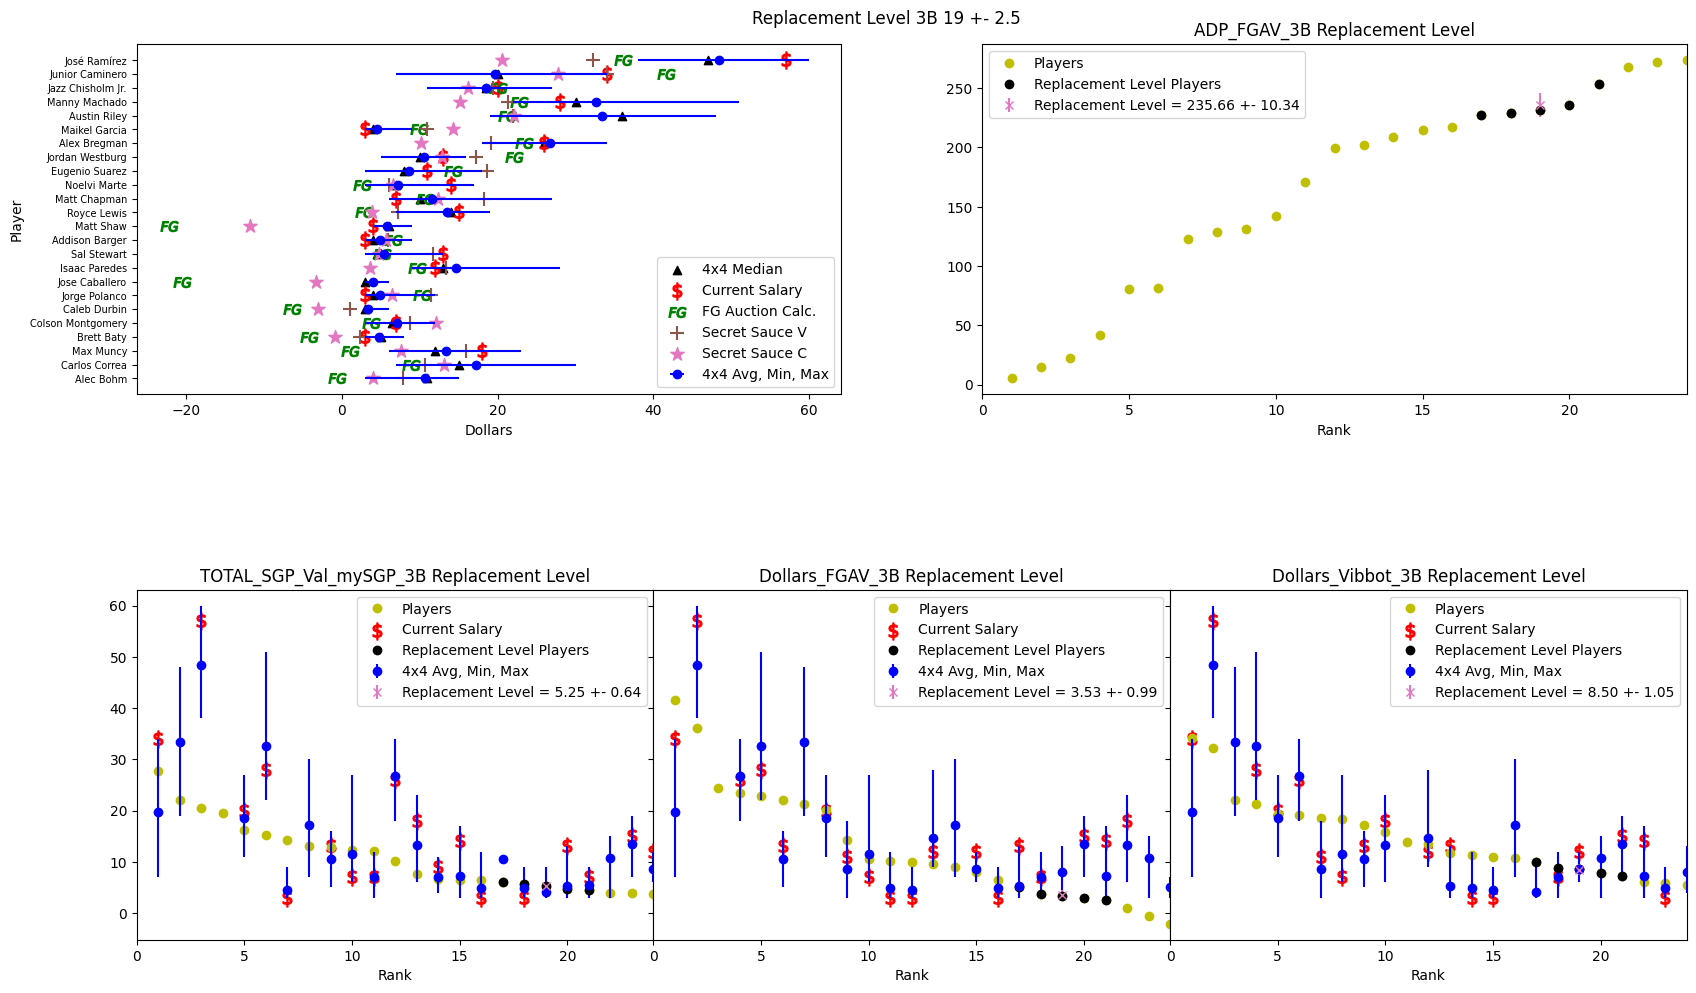

###################################
Position MI Replacement Level = 63
###################################
Replacement Level ADP_FGAV MI 385.31 +- 10.09


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank
1032,Marcelo Mayer,BOS,90.0,Carlos Pérez's K-Dance,2B/SS/3B,40095,371.67,6.73,-8.45,1.0,7.09,7.0,4.0,11.0,9.0,61.0
575,Jonathan India,KCR,NaN,NaN,2B/3B/OF,33619,381.78,6.14,-3.81,5.2,10.50,10.5,10.0,11.0,NaN,62.0
173,J.P. Crawford,SEA,NaN,NaN,SS,18272,382.58,5.77,-8.89,2.4,4.13,3.5,3.0,7.0,NaN,63.0
536,Kody Clemens,MIN,NaN,NaN,1B/2B/OF,35487,393.89,-5.45,-16.19,NaN,3.40,3.0,3.0,7.0,NaN,64.0
799,Joey Ortiz,MIL,NaN,NaN,SS,36743,396.61,3.24,-12.05,NaN,7.50,7.5,5.0,10.0,NaN,65.0


Replacement Level TOTAL_SGP_Val_mySGP MI -0.20 +- 0.36


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank,TOTAL_SGP_Val_mySGP_MI_rank
1124,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,435.14,-0.70,-12.56,NaN,NaN,NaN,NaN,NaN,NaN,73.0,65.0
705,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,-0.38,-13.93,NaN,3.0,3.0,3.0,3.0,NaN,70.0,64.0
931,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,260.58,-0.10,-12.60,1.0,4.4,3.0,3.0,7.0,NaN,43.0,63.0
665,Gabriel Arias,CLE,NaN,NaN,2B/SS,26408,468.25,-0.02,-21.33,NaN,5.0,6.0,3.0,6.0,NaN,78.0,62.0
1427,JJ Wetherholt,STL,197.0,St. CGT VI,2B/SS,45713,999.00,0.22,-11.72,NaN,5.0,4.5,2.0,11.0,6.0,136.0,61.0


Replacement Level Dollars_FGAV MI -11.30 +- 1.16


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank,TOTAL_SGP_Val_mySGP_MI_rank,Dollars_FGAV_MI_rank
1124,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,435.14,-0.70,-12.56,NaN,NaN,NaN,NaN,NaN,NaN,73.0,65.0,65.0
799,Joey Ortiz,MIL,NaN,NaN,SS,36743,396.61,3.24,-12.05,NaN,7.50,7.5,5.0,10.0,NaN,65.0,47.0,64.0
1427,JJ Wetherholt,STL,197.0,St. CGT VI,2B/SS,45713,999.00,0.22,-11.72,NaN,5.00,4.5,2.0,11.0,6.0,136.0,61.0,63.0
660,Tyler Freeman,COL,NaN,NaN,2B/OF,26882,428.31,-2.82,-10.24,1.0,4.86,5.0,3.0,7.0,NaN,72.0,76.0,62.0
886,Josh Smith,TEX,NaN,NaN,1B/SS/3B/OF,37960,353.39,3.62,-9.92,1.0,4.87,5.0,3.0,7.0,NaN,59.0,45.0,61.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


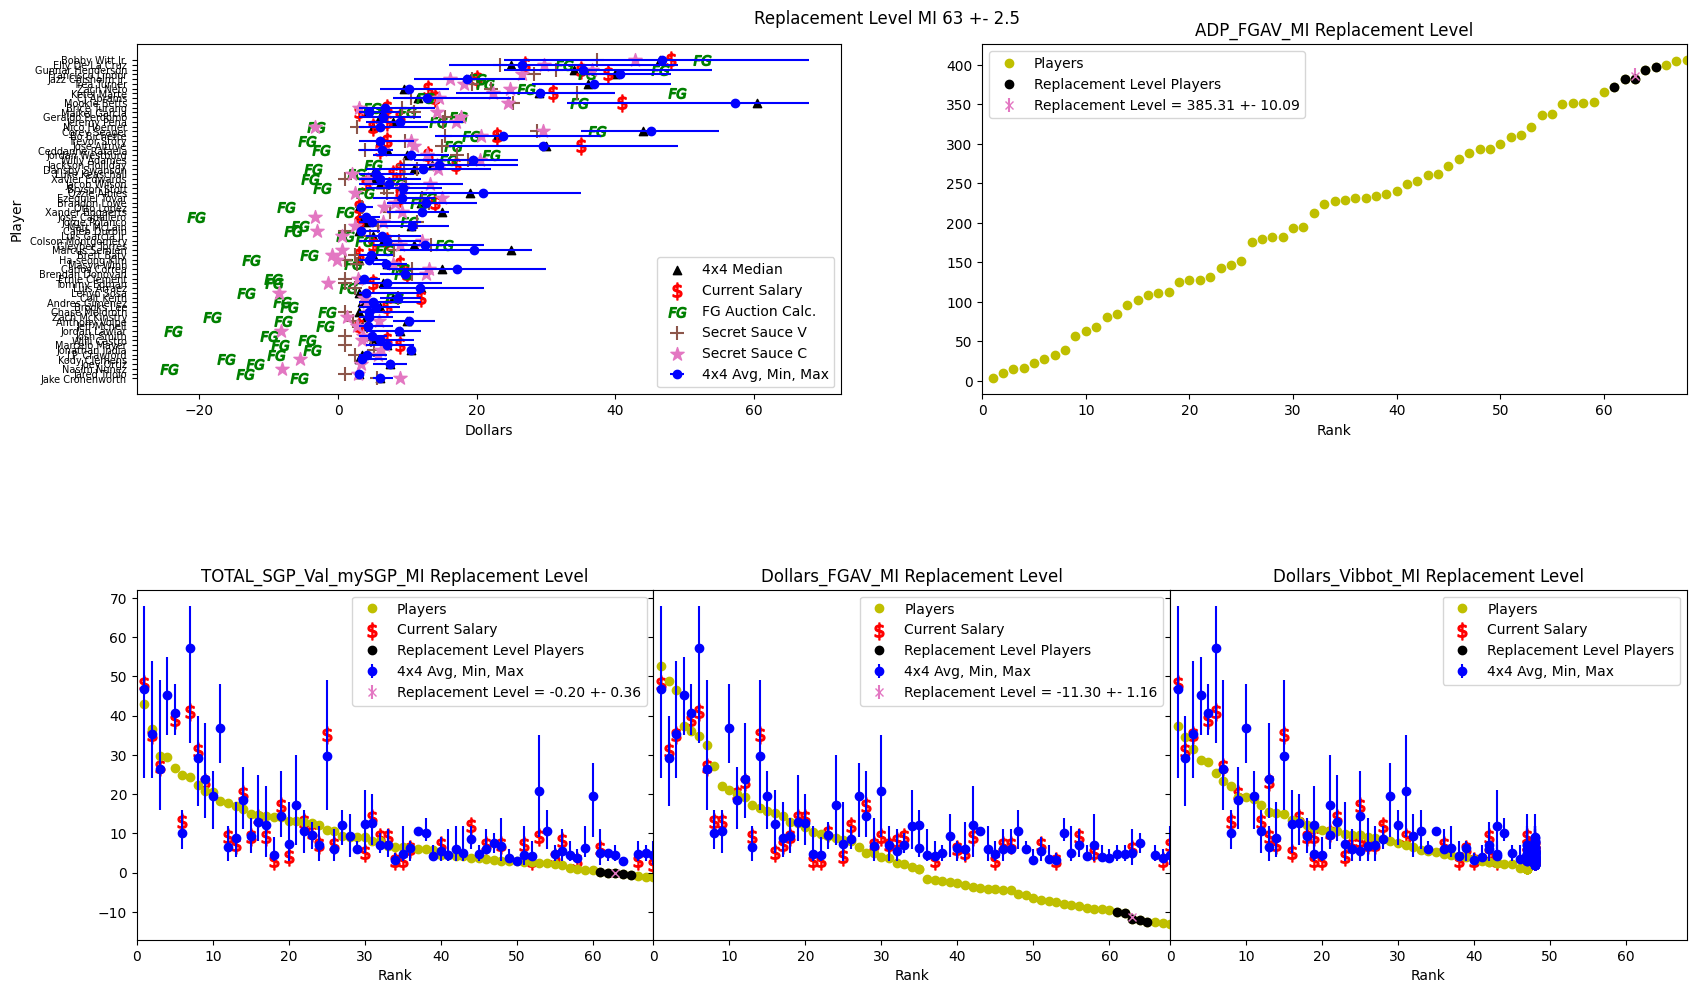

###################################
Position OF Replacement Level = 89
###################################
Replacement Level ADP_FGAV OF 351.45 +- 4.83


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank
859,Jake Mangum,PIT,NaN,NaN,OF,37660,345.72,-10.51,-21.60,NaN,3.00,3.0,3.0,3.0,NaN,87.0
497,Brandon Marsh,PHI,240.0,Largely Indistinguishables,OF,23868,348.06,6.07,-4.37,6.2,5.00,5.0,3.0,8.0,3.0,88.0
165,Jeff Mcneil,ATH,197.0,St. CGT VI,2B/OF,18644,351.89,2.70,-1.84,4.2,4.25,3.5,3.0,8.0,3.0,89.0
886,Josh Smith,TEX,NaN,NaN,1B/SS/3B/OF,37960,353.39,3.62,-9.92,1.0,4.87,5.0,3.0,7.0,NaN,90.0
1227,Cam Smith,HOU,NaN,NaN,OF,45714,358.17,-1.49,-12.17,NaN,6.54,5.0,3.0,17.0,NaN,91.0


Replacement Level TOTAL_SGP_Val_mySGP OF 1.19 +- 0.06


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank,TOTAL_SGP_Val_mySGP_OF_rank
891,Dominic Canzone,SEA,NaN,NaN,OF,37536,332.14,1.13,-3.82,1.5,3.56,3.0,3.0,5.0,NaN,79.0,91.0
677,Wenceel Perez,DET,NaN,NaN,OF,26234,423.17,1.16,-10.60,1.0,4.67,3.0,3.0,9.0,NaN,108.0,90.0
467,Josh Lowe,LAA,NaN,NaN,OF,23752,272.64,1.17,-7.99,1.0,7.50,7.5,5.0,10.0,NaN,70.0,89.0
719,Parker Meadows,DET,NaN,NaN,OF,35450,414.42,1.23,-12.76,NaN,4.60,5.0,3.0,6.0,NaN,105.0,88.0
393,Zach McKinstry,DET,NaN,NaN,SS/3B/OF,33147,337.94,1.27,-18.22,NaN,4.42,4.0,3.0,8.0,NaN,82.0,87.0


Replacement Level Dollars_FGAV OF -7.52 +- 0.36


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank,TOTAL_SGP_Val_mySGP_OF_rank,Dollars_FGAV_OF_rank
467,Josh Lowe,LAA,NaN,NaN,OF,23752,272.64,1.17,-7.99,1.0,7.50,7.5,5.0,10.0,NaN,70.0,89.0,91.0
1155,Dylan Beavers,BAL,241.0,🦫 Beavers in Scoring Position!,OF,42279,309.94,1.54,-7.58,2.3,5.27,4.0,3.0,14.0,14.0,76.0,86.0,90.0
616,Christopher Morel,MIA,NaN,NaN,OF,26080,532.86,-3.29,-7.53,NaN,10.75,11.0,7.0,14.0,NaN,131.0,115.0,89.0
1026,Sal Frelick,MIL,NaN,NaN,OF,40298,206.72,0.11,-7.48,1.1,4.39,3.0,3.0,9.0,NaN,52.0,93.0,88.0
661,George Valera,CLE,NaN,NaN,OF,33605,628.08,-4.32,-6.99,NaN,3.50,3.5,3.0,4.0,NaN,152.0,119.0,87.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


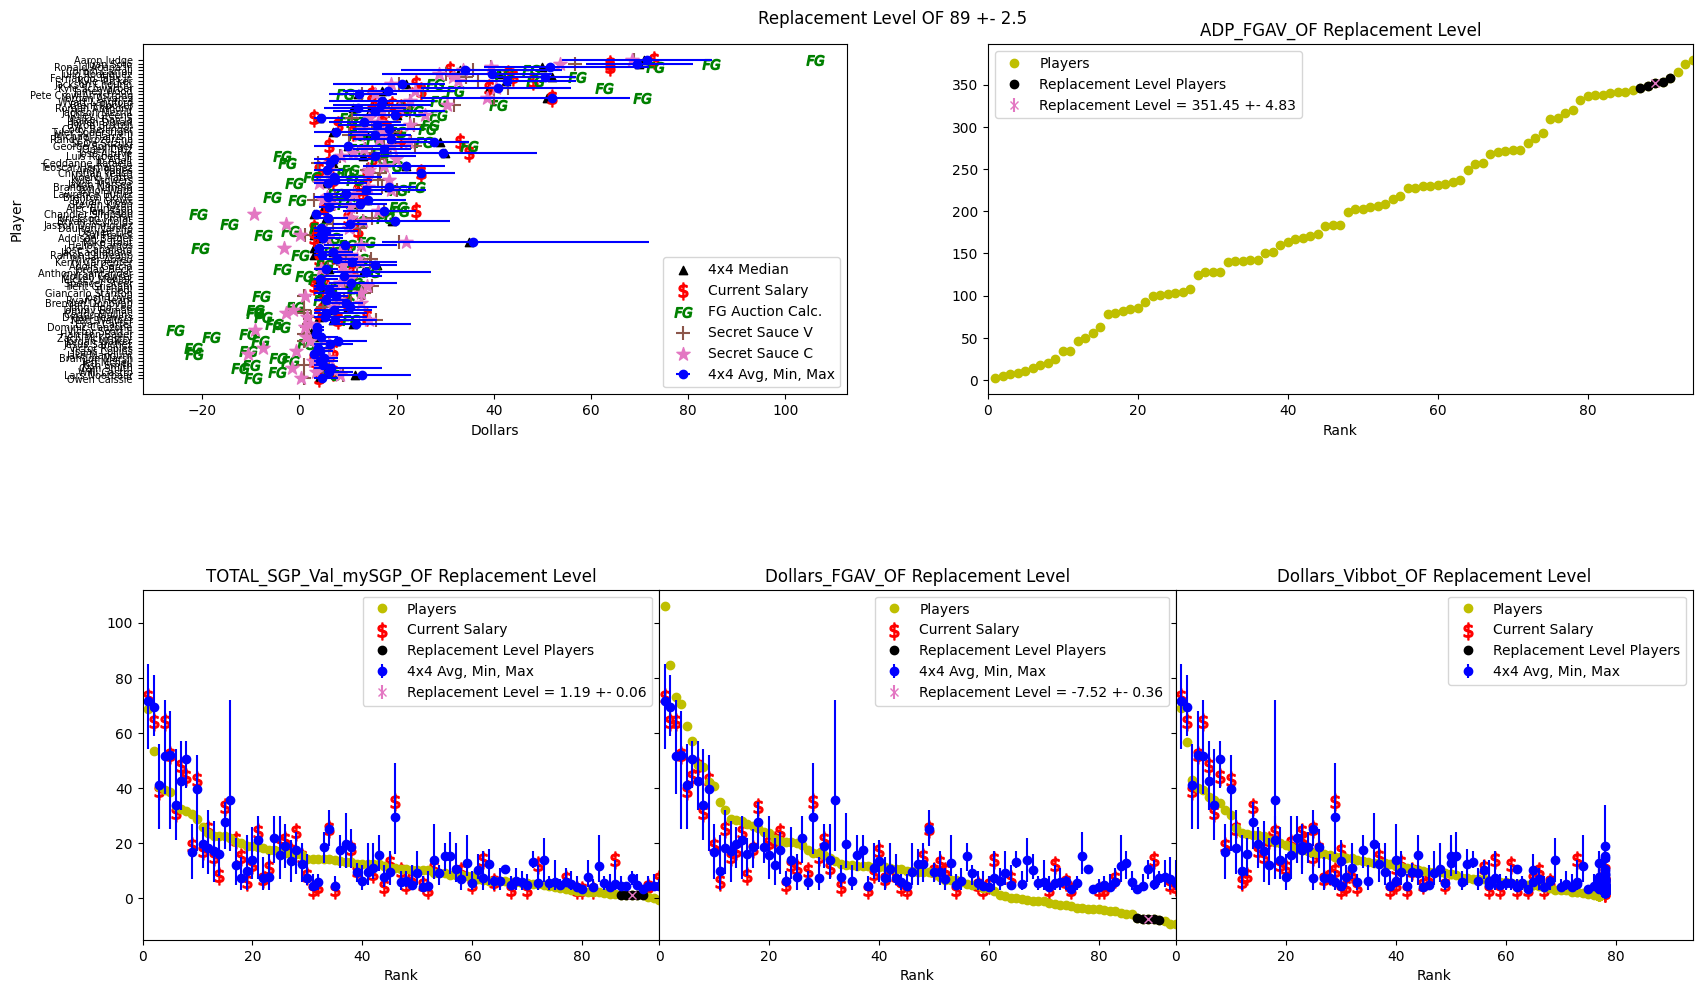

###################################
Position Util Replacement Level = 233
###################################
Replacement Level ADP_FGAV Util 410.43 +- 3.58


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank
585,Romy Gonzalez,BOS,NaN,NaN,1B/2B,34602,406.28,-2.30,-7.23e+00,1.3,3.53,3.0,3.0,7.0,NaN,231.0
188,Tyler O'Neill,BAL,NaN,NaN,OF,19296,406.89,5.37,-3.26e-03,7.1,13.11,13.0,11.0,17.0,NaN,232.0
241,Lane Thomas,KCR,NaN,NaN,OF,21041,412.31,-1.55,-1.01e+01,1.0,6.50,6.5,6.0,7.0,NaN,233.0
705,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,-0.38,-1.39e+01,NaN,3.00,3.0,3.0,3.0,NaN,234.0
156,Ryan McMahon,NYY,NaN,NaN,3B,18328,414.08,-2.92,-1.67e+01,3.5,7.57,8.5,3.0,16.0,NaN,235.0


Replacement Level TOTAL_SGP_Val_mySGP Util -2.08 +- 0.37


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank,TOTAL_SGP_Val_mySGP_Util_rank
502,Jake Meyers,HOU,NaN,NaN,OF,26783,437.64,-2.42,-10.82,NaN,3.60,3.0,3.0,5.0,NaN,249.0,235.0
592,Griffin Conine,MIA,NaN,NaN,OF,35928,500.44,-2.30,-13.86,NaN,3.00,3.0,3.0,3.0,NaN,276.0,234.0
585,Romy Gonzalez,BOS,NaN,NaN,1B/2B,34602,406.28,-2.30,-7.23,1.3,3.53,3.0,3.0,7.0,NaN,231.0,233.0
702,Davis Schneider,TOR,NaN,NaN,2B/OF,26734,591.94,-1.79,-9.35,3.0,4.00,3.5,3.0,7.0,NaN,318.0,232.0
1153,Cole Young,SEA,NaN,NaN,2B/SS,42582,523.58,-1.57,-17.65,NaN,4.20,4.0,3.0,7.0,NaN,285.0,231.0


Replacement Level Dollars_FGAV Util -9.83 +- 0.13


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank,TOTAL_SGP_Val_mySGP_Util_rank,Dollars_FGAV_Util_rank
196,Luis Torrens,NYM,NaN,NaN,C,19981,667.53,-7.80,-9.93,NaN,NaN,NaN,NaN,NaN,NaN,348.0,302.0,235.0
886,Josh Smith,TEX,NaN,NaN,1B/SS/3B/OF,37960,353.39,3.62,-9.92,1.0,4.87,5.0,3.0,7.0,NaN,205.0,164.0,234.0
580,Nick Fortes,TBR,NaN,NaN,C,34653,613.33,-8.67,-9.88,NaN,NaN,NaN,NaN,NaN,NaN,326.0,321.0,233.0
234,Jose Trevino,CIN,NaN,NaN,C,20399,702.08,-8.82,-9.79,NaN,NaN,NaN,NaN,NaN,NaN,362.0,322.0,232.0
925,Owen Caissie,MIA,55.0,Jack Klugman's Second Best Lung,OF,38367,379.06,0.37,-9.62,1.0,4.60,4.0,3.0,8.0,4.0,213.0,203.0,231.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


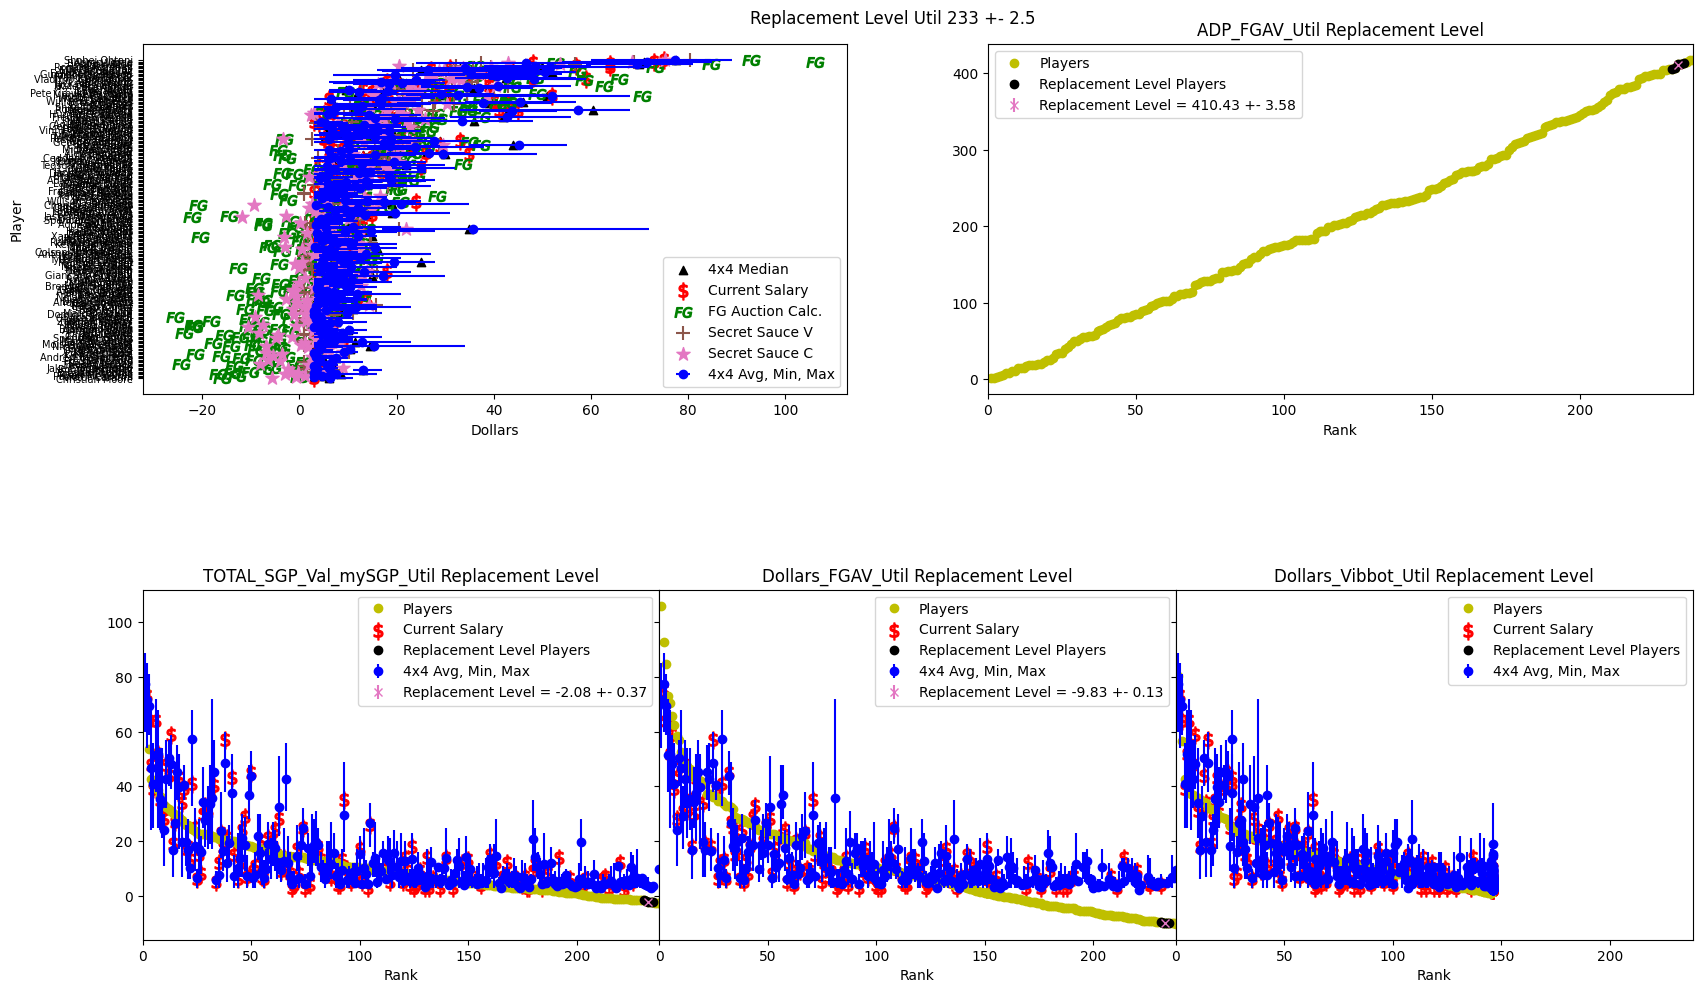

###################################
Position SP Replacement Level = 150
###################################
Replacement Level ADP_FGAV SP 548.52 +- 7.40


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank
80,Eduardo Rodriguez,ARI,NaN,NaN,SP,13335,540.00,2.22,-27.31,NaN,7.00,7.0,7.0,7.0,NaN,148.0
940,Carmen Mlodzinski,PIT,NaN,NaN,SP/RP,38403,541.14,5.92,-1.61,1.5,3.00,3.0,3.0,3.0,NaN,149.0
387,Corbin Burnes,ARI,NaN,NaN,SP,23813,551.50,1.34,13.42,3.2,14.18,13.0,7.0,24.0,NaN,150.0
1045,Robert Gasser,MIL,NaN,NaN,SP/RP,40476,554.72,6.54,-5.01,NaN,3.75,3.5,3.0,5.0,NaN,151.0
1121,Max Scherzer,NaN,NaN,NaN,SP,4514,555.22,NaN,-16.59,NaN,5.00,4.5,3.0,8.0,NaN,152.0


Replacement Level TOTAL_SGP_Val_mySGP SP 2.06 +- 0.12


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank
111,Zach Eflin,BAL,NaN,NaN,SP,23612,401.39,1.93,-21.29,NaN,9.75,10.5,4.0,16.0,NaN,116.0,152.0
1112,Justin Wrobleski,LAD,NaN,NaN,SP/RP,41926,596.92,1.97,-7.00,NaN,3.00,3.0,3.0,3.0,NaN,162.0,151.0
52,Seth Lugo,KCR,NaN,NaN,SP,23701,358.22,2.03,-33.28,NaN,8.40,8.0,7.0,11.0,NaN,103.0,150.0
1105,Jack Dreyer,LAD,NaN,NaN,SP/RP,41400,742.31,2.13,-5.62,NaN,3.57,3.0,3.0,5.0,NaN,194.0,149.0
80,Eduardo Rodriguez,ARI,NaN,NaN,SP,13335,540.00,2.22,-27.31,NaN,7.00,7.0,7.0,7.0,NaN,148.0,148.0


Replacement Level Dollars_FGAV SP -11.69 +- 0.25


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank,Dollars_FGAV_SP_rank
1093,Carlos Rodriguez,MIL,NaN,NaN,SP/RP,40951,999.00,-0.13,-12.01,NaN,NaN,NaN,NaN,NaN,NaN,220.0,188.0,152.0
148,Jon Gray,NaN,NaN,NaN,SP/RP,18244,999.00,NaN,-11.77,NaN,3.00,3.0,3.0,3.0,NaN,220.0,231.0,151.0
663,Taj Bradley,MIN,NaN,NaN,SP,35367,410.53,6.24,-11.75,NaN,8.25,8.0,4.0,15.0,NaN,118.0,106.0,150.0
1160,AJ Blubaugh,HOU,NaN,NaN,SP/RP,42340,568.00,0.39,-11.56,NaN,3.33,3.0,3.0,4.0,NaN,156.0,180.0,149.0
916,Max Meyer,MIA,NaN,NaN,SP,38307,408.25,7.42,-11.34,NaN,4.07,4.0,3.0,8.0,NaN,117.0,92.0,148.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


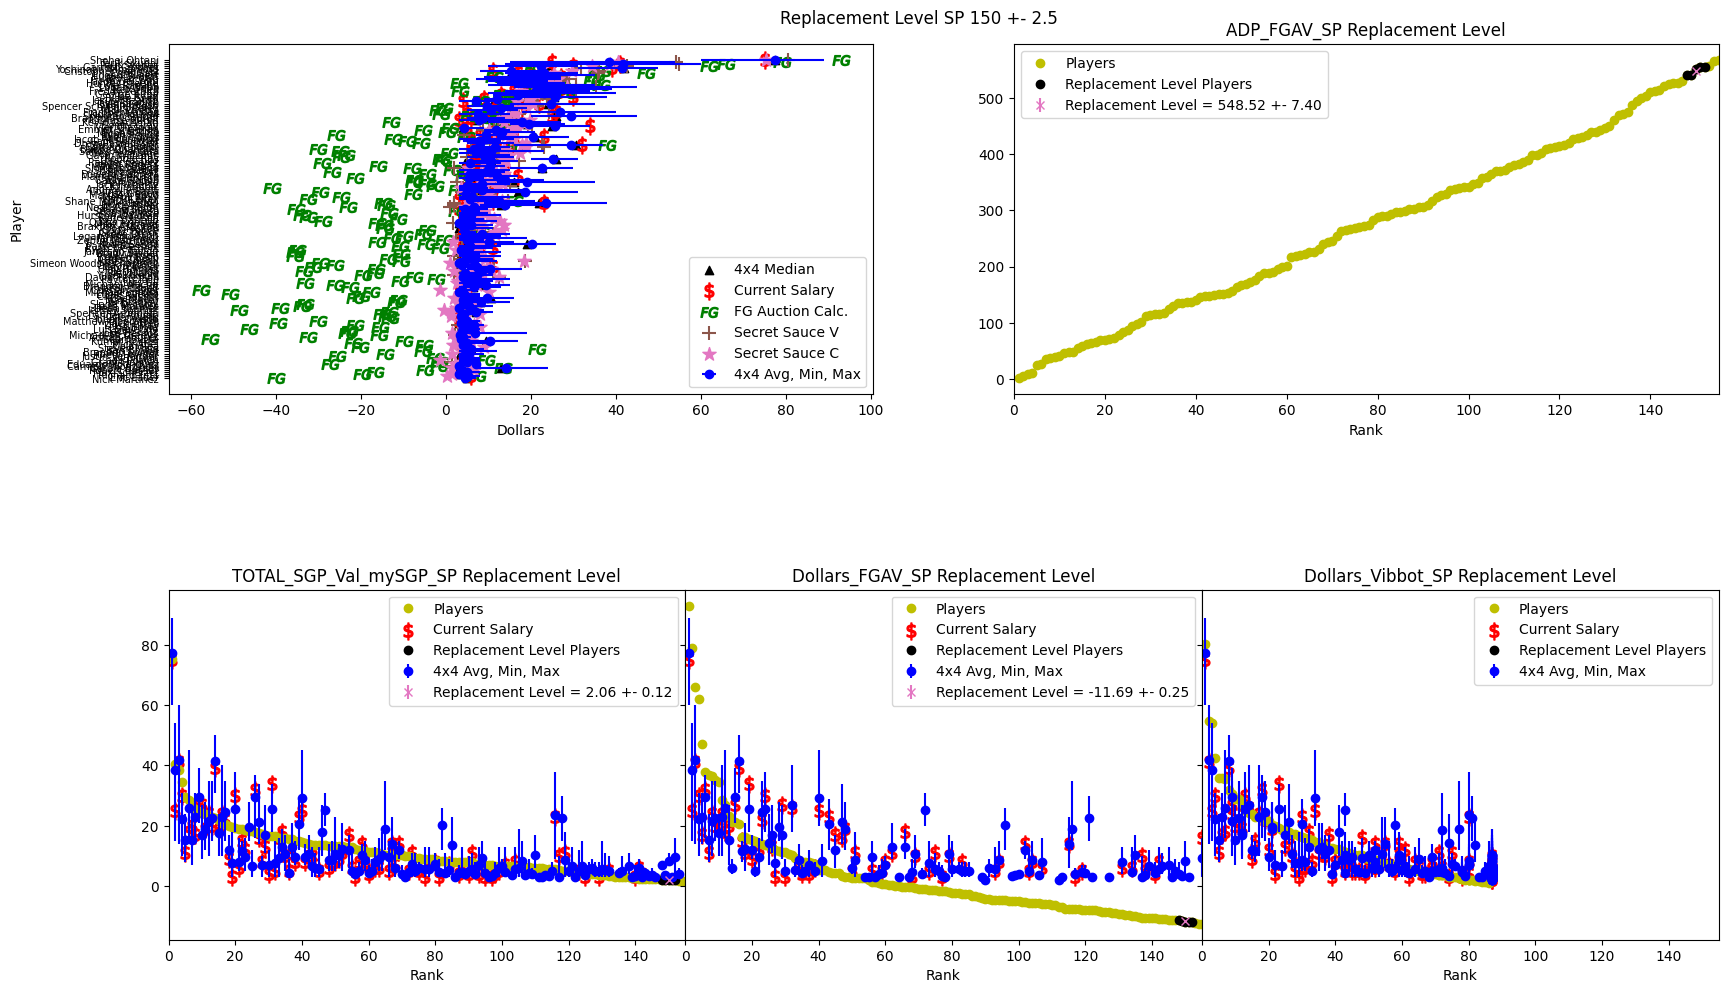

###################################
Position RP Replacement Level = 65
###################################
Replacement Level ADP_FGAV RP 449.59 +- 5.82


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank
274,Tanner Scott,LAD,NaN,NaN,RP,21075,443.64,6.08,4.12,3.1,7.67,7.0,7.0,9.0,NaN,63.0
239,Luke Weaver,NYM,NaN,NaN,RP,18380,446.44,-2.45,1.08,NaN,4.93,5.0,3.0,7.0,NaN,64.0
410,JoJo Romero,STL,NaN,NaN,RP,23818,448.33,4.49,-2.36,1.9,3.67,3.0,3.0,6.0,NaN,65.0
315,Phil Maton,CHC,247.0,Roberto Big Piece and the 69ers,RP,22809,450.61,6.06,-3.09,2.9,3.53,3.0,3.0,6.0,3.0,66.0
464,Tony Santillan,CIN,NaN,NaN,RP,22679,458.94,-8.46,-16.95,NaN,3.00,3.0,3.0,3.0,NaN,67.0


Replacement Level TOTAL_SGP_Val_mySGP RP 5.19 +- 0.19


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank,TOTAL_SGP_Val_mySGP_RP_rank
986,J.T. Ginn,ATH,NaN,NaN,SP/RP,38339,525.97,4.99,-2.56,NaN,5.00,4.0,3.0,8.0,NaN,87.0,67.0
1209,Connelly Early,BOS,185.0,Chili Dog MVP,SP/RP,44515,222.33,5.03,2.64,6.7,8.58,8.0,3.0,18.0,11.0,27.0,66.0
343,A.J. Minter,NYM,NaN,NaN,RP,23679,745.31,5.15,8.48,4.0,3.71,3.0,3.0,5.0,NaN,179.0,65.0
933,Jared Koenig,MIL,NaN,NaN,RP,38641,750.33,5.37,3.44,2.8,3.00,3.0,3.0,3.0,NaN,212.0,64.0
175,Hunter Harvey,CHC,NaN,NaN,RP,18283,530.08,5.41,8.96,3.1,3.00,3.0,3.0,3.0,NaN,89.0,63.0


Replacement Level Dollars_FGAV RP 2.79 +- 0.17


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank,TOTAL_SGP_Val_mySGP_RP_rank,Dollars_FGAV_RP_rank
1209,Connelly Early,BOS,185.0,Chili Dog MVP,SP/RP,44515,222.33,5.03,2.64,6.7,8.58,8.0,3.0,18.0,11.0,27.0,66.0,67.0
559,Bennett Sousa,HOU,NaN,NaN,RP,35941,999.00,1.75,2.69,NaN,4.50,4.5,3.0,6.0,NaN,220.0,112.0,66.0
673,Angel Zerpa,MIL,NaN,NaN,RP,25903,728.69,5.61,2.69,NaN,NaN,NaN,NaN,NaN,NaN,162.0,62.0,65.0
209,Aaron Bummer,ATL,NaN,NaN,RP,29222,999.00,7.12,2.88,3.5,3.00,3.0,3.0,3.0,NaN,220.0,45.0,64.0
307,Pete Fairbanks,MIA,NaN,NaN,RP,20435,90.22,7.75,3.04,3.0,5.84,5.0,3.0,10.0,NaN,13.0,42.0,63.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


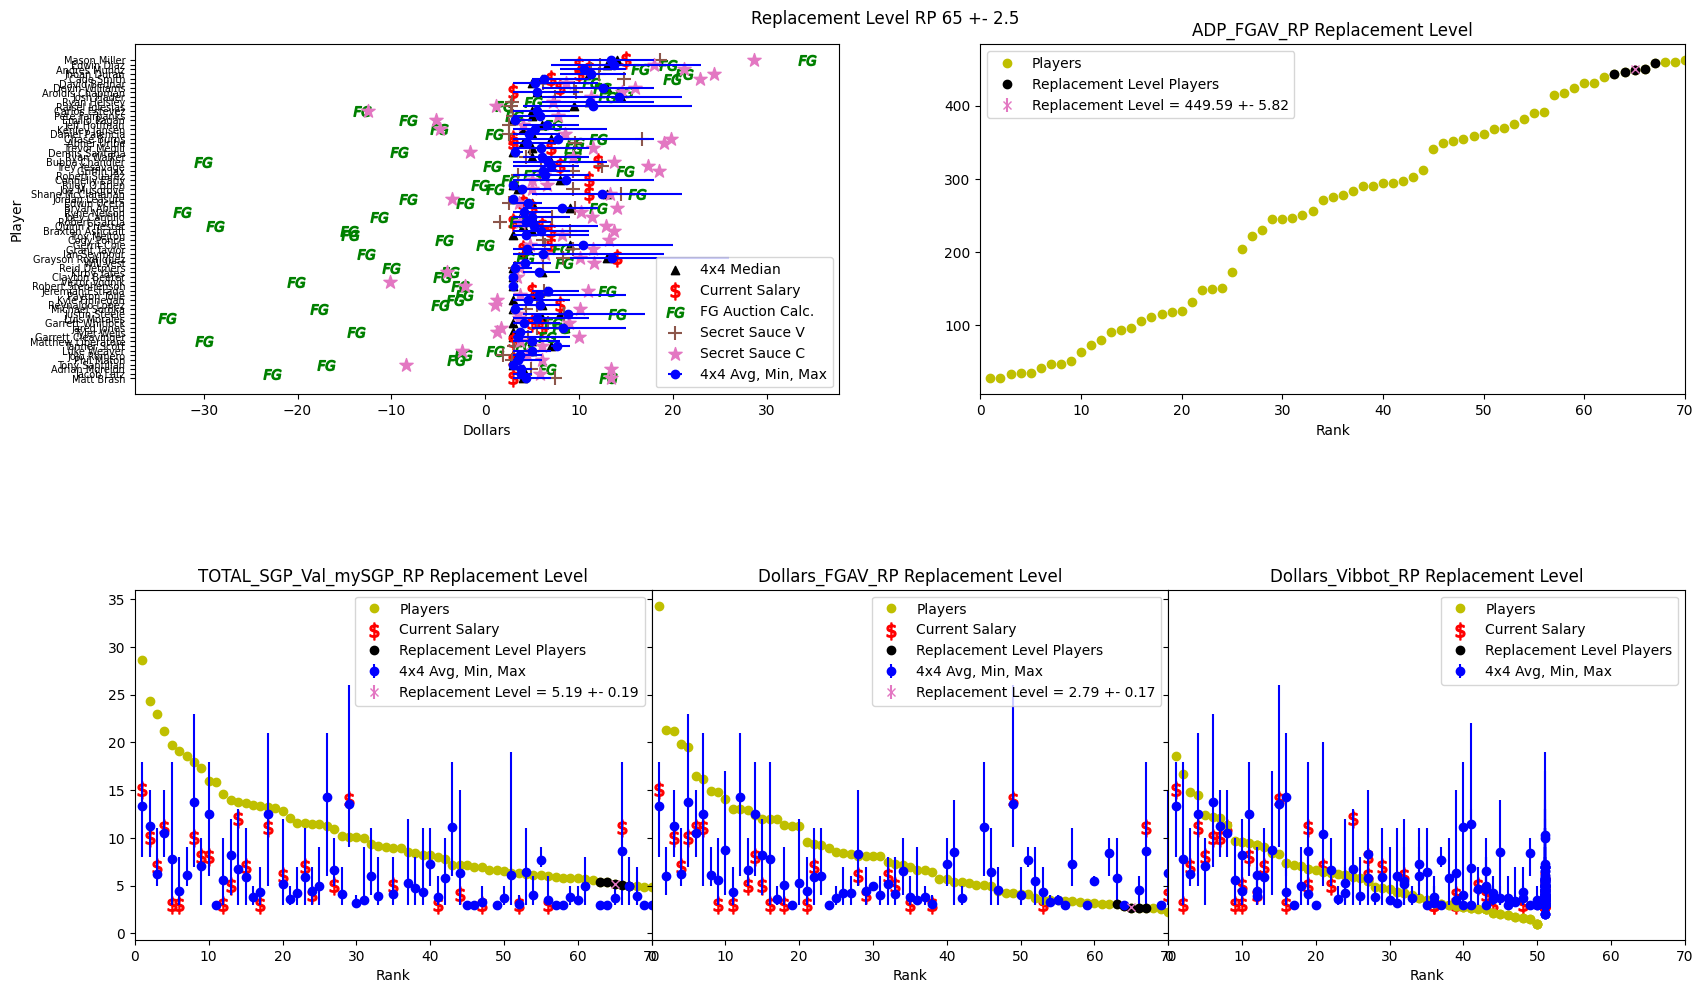

###################################
Position P Replacement Level = 215
###################################
Replacement Level ADP_FGAV P 544.72 +- 3.88


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank
80,Eduardo Rodriguez,ARI,NaN,NaN,SP,13335,540.00,2.22,-27.31,NaN,7.00,7.0,7.0,7.0,NaN,213.0
940,Carmen Mlodzinski,PIT,NaN,NaN,SP/RP,38403,541.14,5.92,-1.61,1.5,3.00,3.0,3.0,3.0,NaN,214.0
760,Kyle Leahy,STL,NaN,NaN,RP,35030,546.36,-7.02,-27.12,NaN,3.33,3.0,3.0,4.0,NaN,215.0
960,Louis Varland,TOR,253.0,Roar from 34,RP,37202,547.56,6.33,6.40,NaN,3.09,3.0,3.0,4.0,3.0,216.0
179,Mark Leiter Jr.,ATH,NaN,NaN,RP,19574,548.53,-6.61,-5.95,NaN,4.33,3.0,3.0,7.0,NaN,217.0


Replacement Level TOTAL_SGP_Val_mySGP P 2.03 +- 0.08


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank,TOTAL_SGP_Val_mySGP_P_rank
111,Zach Eflin,BAL,NaN,NaN,SP,23612,401.39,1.93,-21.29,NaN,9.75,10.5,4.0,16.0,NaN,157.0,217.0
1112,Justin Wrobleski,LAD,NaN,NaN,SP/RP,41926,596.92,1.97,-7.00,NaN,3.00,3.0,3.0,3.0,NaN,242.0,216.0
52,Seth Lugo,KCR,NaN,NaN,SP,23701,358.22,2.03,-33.28,NaN,8.40,8.0,7.0,11.0,NaN,138.0,215.0
1,Caleb Thielbar,CHC,NaN,NaN,RP,6225,749.22,2.08,0.01,NaN,3.00,3.0,3.0,3.0,NaN,344.0,214.0
1105,Jack Dreyer,LAD,NaN,NaN,SP/RP,41400,742.31,2.13,-5.62,NaN,3.57,3.0,3.0,5.0,NaN,315.0,213.0


Replacement Level Dollars_FGAV P -4.56 +- 0.04


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank,TOTAL_SGP_Val_mySGP_P_rank,Dollars_FGAV_P_rank
1069,Joe Rock,NaN,NaN,NaN,SP/RP,40747,750.72,NaN,-4.61,NaN,NaN,NaN,NaN,NaN,NaN,367.0,486.0,217.0
567,Cole Sands,MIN,NaN,NaN,RP,35878,509.42,-0.20,-4.59,NaN,3.00,3.0,3.0,3.0,NaN,197.0,277.0,216.0
1218,Andrew Walters,NaN,NaN,NaN,RP,44588,999.00,NaN,-4.56,NaN,NaN,NaN,NaN,NaN,NaN,370.0,486.0,215.0
95,Steven Okert,HOU,NaN,NaN,RP,18421,749.83,-1.98,-4.54,NaN,3.57,3.0,3.0,9.0,NaN,356.0,315.0,214.0
269,Jack Flaherty,DET,185.0,Chili Dog MVP,SP,20920,217.64,13.40,-4.52,11.8,8.56,8.0,5.0,15.0,8.0,84.0,61.0,213.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/1414187249.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


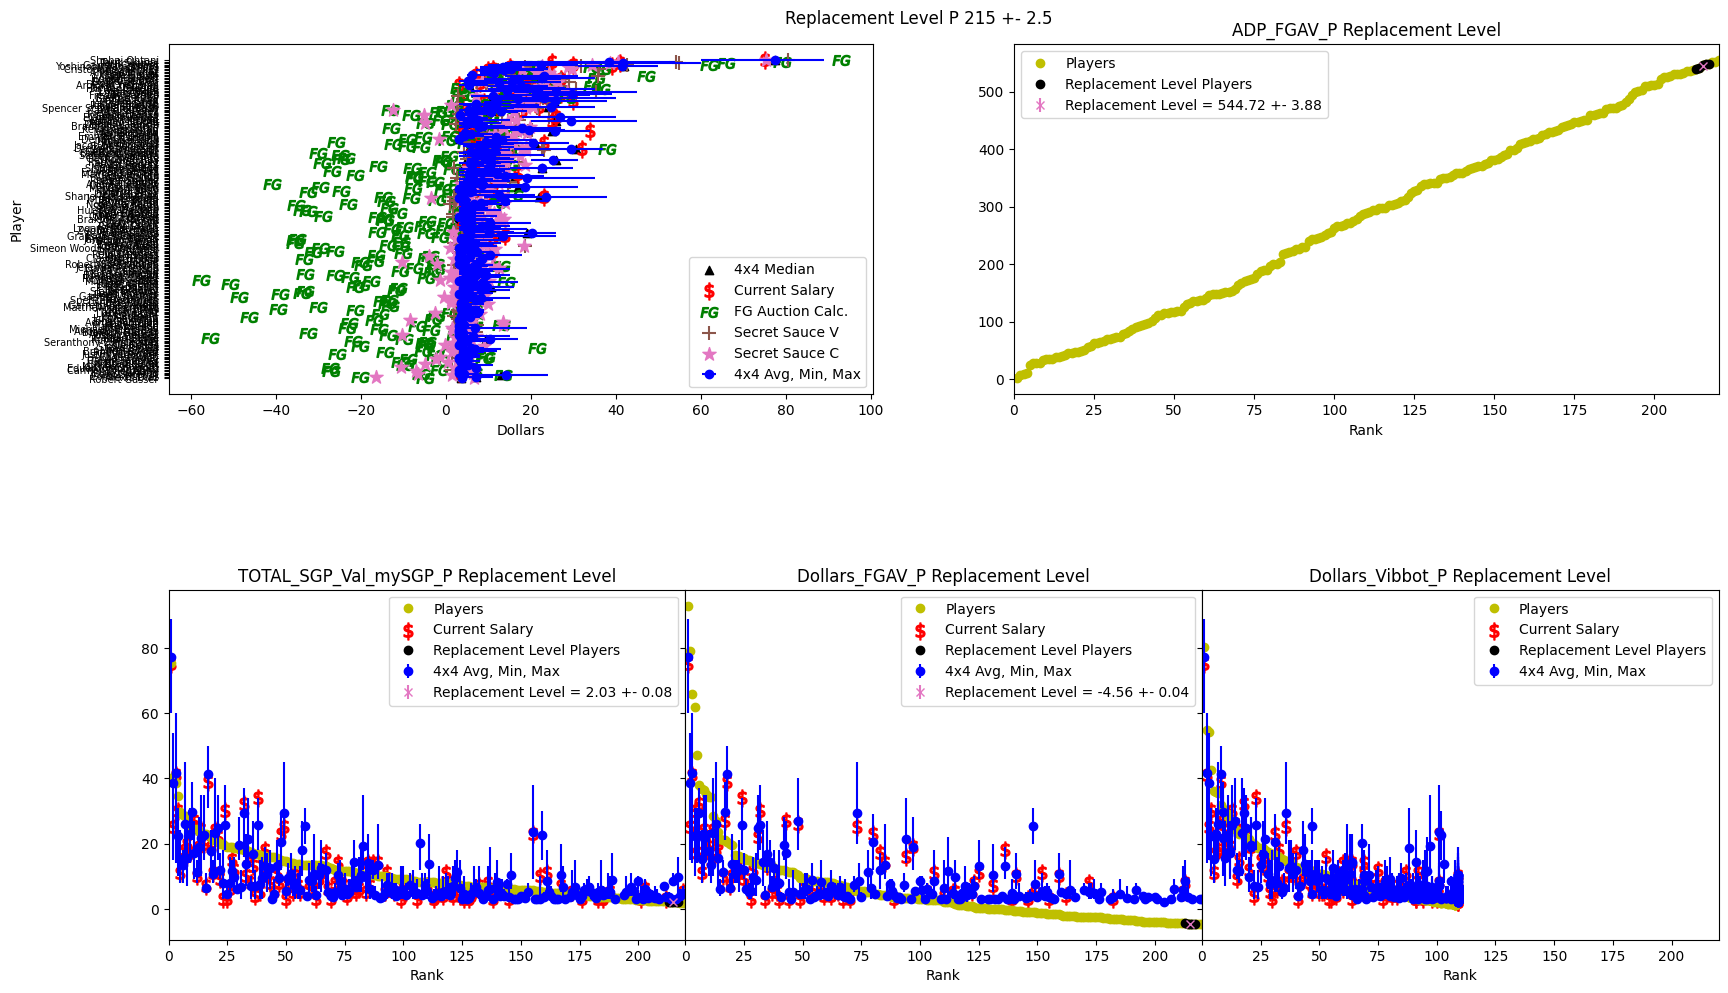

In [101]:
Replacement_Stats_df = pd.DataFrame()

pos_idx = 0

for pos,repl_level_mid in Replacement_Level.items():
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.split('/'))]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Full_Merge_sorted_df[~Full_Merge_sorted_df['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"2B" in x.split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"SS" in x.split('/'))]

        ]).sort_values(by=['ADP_FGAV']).drop_duplicates(keep='first')

    proj_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]
    fig0 = plt.figure(figsize=(20,10))
    outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
    upper_axes = outer_subfig[0].subplots(1, 2)
    lower_gs = outer_subfig[1].add_gridspec(1,len(Proj_cols)-1, wspace=0)
    lower_axes = lower_gs.subplots(sharey=True) # Because ADP is above
    #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))
    for proj_col in Proj_cols:
        this_axis = lower_axes[proj_idx-1]
        is_rank = False
        if 'ADP' in proj_col:
            is_rank = True
            this_axis = upper_axes[1]
        This_Pos_df[f'{proj_col}_{pos}_rank'] = This_Pos_df[f'{proj_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
        # this_axis = axs

        if proj_idx == 0:
            quick_plotting_fn(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max],upper_axes[0])
        
        Replacement_level_df = This_Pos_df[(This_Pos_df[f'{proj_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{proj_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ].sort_values([f'{proj_col}_{pos}_rank'], ascending=is_rank)
        mean = Replacement_level_df[proj_col].mean()
        std = Replacement_level_df[proj_col].std()
        Replacement_Stats_df = pd.concat([
            Replacement_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat': proj_col,
                'mean':mean,
                'std':std
            }])
        ])

        this_axis.plot(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col], 'yo', label='Players')
        if not is_rank:
            this_axis.errorbar(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                yerr=[
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                ],
                fmt='o',
                color='blue',
                label='4x4 Avg, Min, Max'
            )
            this_axis.scatter(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Salary'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                marker='$\\$$',
                color='red',
                s=150,
                label='Current Salary'
            )
        if len(Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank']) > 0.:
            this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
            
            print(f'Replacement Level {proj_col} {pos} {mean:0.2f} +- {std:0.2f}')
            display(Replacement_level_df)
        this_axis.plot(Replacement_level_df[f'{proj_col}_{pos}_rank'],Replacement_level_df[proj_col], 'ko',label='Replacement Level Players')
        this_axis.set_title(f'{proj_col}_{pos} Replacement Level')
        #this_axis.set_ylabel(proj_col)
        this_axis.set_xlabel('Rank')
        # ymin = 0.95*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].min()
        # ymax = 1.05*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].max()
        xmin=0.
        xmax = x_max
        # this_axis.set_ylim([ymin,ymax])
        this_axis.set_xlim([xmin,xmax])
        this_axis.legend(loc='upper right')
        if is_rank:
            this_axis.legend(loc='upper left')

        #print(Replacement_level_df.head(Replacement_window[pos]))
        # quick_plotting_fn(Replacement_level_df,this_axis)
        # plt.tight_layout()    
        # plt.show()
        #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
        proj_idx+=1
    pos_idx+=1   
    fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
    plt.tight_layout()
    plt.show()

# Scoring Stat Level

In [102]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [103]:
Scoring_Categories_Pitching

['SO', 'HR9', 'ERA', 'WHIP']

In [104]:
Batting_value_columns = {
    'R':['TOTAL_SGP_Val_mySGP','R_mySGP','R_SGP_raw_mySGP','R_SGP_norm_mySGP','R_SGP_Val_mySGP','mR_FGAV'],
    'HR':['TOTAL_SGP_Val_mySGP','HR_mySGP','HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','HR_SGP_Val_mySGP','mHR_FGAV'],
    'OBP':['TOTAL_SGP_Val_mySGP','OBP_mySGP','OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','OBP_SGP_Val_mySGP','mOBP_FGAV'],
    'SLG':['TOTAL_SGP_Val_mySGP','SLG_mySGP','SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP','SLG_SGP_Val_mySGP','mSLG_FGAV']
}

Pitching_value_columns = {
    'SO':['TOTAL_SGP_Val_mySGP','SO_mySGP','SO_SGP_raw_mySGP','SO_SGP_norm_mySGP','SO_SGP_Val_mySGP','mSO_FGAV',],
    'HR9':['TOTAL_SGP_Val_mySGP','HR9_mySGP','HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP','HR9_SGP_Val_mySGP','mHR_FGAV',],
    'ERA':['TOTAL_SGP_Val_mySGP','ERA_mySGP','ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP','ERA_SGP_Val_mySGP','mERA_FGAV',],
    'WHIP':['TOTAL_SGP_Val_mySGP','WHIP_mySGP','WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP','WHIP_SGP_Val_mySGP','mWHIP_FGAV',]
}

In [105]:
All_Batting_cols = []
for stat,cols in Batting_value_columns.items():
    All_Batting_cols += cols
    All_Batting_cols = list(set(All_Batting_cols))

All_Pitching_cols = []
for stat,cols in Pitching_value_columns.items():
    All_Pitching_cols += cols
    All_Pitching_cols = list(set(All_Pitching_cols))

In [106]:
list(Full_Merge_df.columns)

['FG ID',
 'Team',
 'G_mySGP',
 'PA_mySGP',
 'AB_mySGP',
 'H_mySGP',
 '1B_mySGP',
 '2B_mySGP',
 '3B_mySGP',
 'HR_mySGP',
 'R_mySGP',
 'RBI_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'SF_mySGP',
 'WAR_mySGP',
 'ADP_mySGP',
 'POS_mySGP',
 'Ottoneu ID',
 'Ottoneu Positions',
 'Name',
 'OBP_mySGP',
 'TB_mySGP',
 'SLG_mySGP',
 'Pos Place_mySGP',
 'R_SGP_raw_mySGP',
 'HR_SGP_raw_mySGP',
 'OBP_SGP_raw_mySGP',
 'SLG_SGP_raw_mySGP',
 'TOTAL_SGP_raw_mySGP',
 'R_SGP_repl_mySGP',
 'Repl_Pos_mySGP',
 'R_SGP_norm_mySGP',
 'HR_SGP_repl_mySGP',
 'HR_SGP_norm_mySGP',
 'OBP_SGP_repl_mySGP',
 'OBP_SGP_norm_mySGP',
 'SLG_SGP_repl_mySGP',
 'SLG_SGP_norm_mySGP',
 'TOTAL_SGP_mySGP',
 'TOTAL_SGP_Rank_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'R_SGP_Val_mySGP',
 'HR_SGP_Val_mySGP',
 'OBP_SGP_Val_mySGP',
 'SLG_SGP_Val_mySGP',
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'SO_mySGP',
 'HR9_mySGP',
 'ERA_mySGP',
 'WHIP_mySGP',
 'SO_SGP_raw_mySGP',
 'HR9_SGP_

In [107]:
Sorted_Hitter_df = Full_Merge_df[~Full_Merge_df['Ottoneu Positions'].isin(['SP','RP','SP/RP'])][[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    #'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]+ All_Batting_cols].sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

Sorted_Pitcher_df = Full_Merge_df[Full_Merge_df['Ottoneu Positions'].isin(['SP','RP','SP/RP','Util/SP'])][[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    #'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]+ All_Pitching_cols].sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

In [108]:
import warnings
#warnings.filterwarnings('ignore', category=UserWarning)
import os, errno

os.makedirs(League_path+'/Replacement_Level_'+Replacement_Calc_date, exist_ok=True)

pos_idx = 0

Players_out = []#['45713']
Players_in = []#['21156']

Recalc_Replacement_Level = pd.DataFrame()

for pos,repl_level_mid in Replacement_Level.items():
    Hitter_or_Pitcher_sorted = Sorted_Hitter_df if pos in Hitting_Pos else Sorted_Pitcher_df

    This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.split('/'))]
    This_Pos_Repl_df = Hitter_Pitcher_Repl_SGP_df[Hitter_Pitcher_Repl_SGP_df['Ottoneu Positions'] == pos]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Hitter_or_Pitcher_sorted[~Hitter_or_Pitcher_sorted['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"2B" in x.split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"SS" in x.split('/'))]

        ]).sort_values(by=['TOTAL_SGP_Val_mySGP'])
        This_Pos_Repl_df = pd.DataFrame(Hitter_Pitcher_Repl_SGP_df.loc[Hitter_Pitcher_Repl_SGP_df[Hitter_Pitcher_Repl_SGP_df['Ottoneu Positions'].isin(['2B','SS'])]['TOTAL_SGP_raw_mySGP'].idxmin()]).T.reset_index(drop=True)

    if (This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)].shape[0] == 0) & \
        (This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)].shape[0] == 0) & \
            (len(Players_out)+ len(Players_in) > 0):

        continue

    Replacement_Stats_df = pd.DataFrame()
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    for score_cat,Stat_col_list in Batting_value_columns.items() if pos in Hitting_Pos else Pitching_value_columns.items():
        stat_idx = 0
        x_max = repl_level_mid+(2*Replacement_window[pos])
        fig0 = plt.figure(figsize=(20,10))
        outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
        upper_axes = outer_subfig[0].subplots(1, 2)
        lower_gs = outer_subfig[1].add_gridspec(1,len(Stat_col_list)-1, wspace=0.5)
        lower_axes = lower_gs.subplots(sharey=False) # Because ADP is above
        #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))

        for stat_col in Stat_col_list:
            this_axis = lower_axes[stat_idx-1]
            is_rank = False
            if 'TOTAL_SGP_Val_mySGP' == stat_col:
                this_axis = upper_axes[1]
            This_Pos_df[f'{stat_col}_{pos}_rank'] = This_Pos_df[f'{stat_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
            # this_axis = axs

            if stat_idx == 0:
                quick_plotting_fn(This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max],upper_axes[0])
            
            Replacement_level_df = This_Pos_df[(This_Pos_df[f'{stat_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{stat_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                                ].sort_values([f'{stat_col}_{pos}_rank'], ascending=is_rank)
            mean = Replacement_level_df[stat_col].mean()
            std = Replacement_level_df[stat_col].std()
            Replacement_Stats_df = pd.concat([
                Replacement_Stats_df,
                pd.DataFrame([{
                    'POS':pos,
                    'Stat': stat_col,
                    'mean':mean,
                    'std':std
                }])
            ])

            this_axis.plot(This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col], 'yo', label='Players')
            if This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)].shape[0] != 0:
                this_axis.plot(This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)][stat_col], 'r*', label='Player Out',markersize=15)
            if This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)].shape[0] != 0:
                this_axis.plot(This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)][stat_col], 'g*', label='Player In',markersize=15)
            if (not is_rank) & (stat_idx == 0):
                this_axis.errorbar(
                    y=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                    x=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],
                    yerr=[
                        This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                        This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                    ],
                    fmt='o',
                    color='blue',
                    label='4x4 Avg, Min, Max'
                )
                this_axis.scatter(
                    y=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Salary'],
                    x=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],
                    marker='$\\$$',
                    color='red',
                    s=150,
                    label='Current Salary'
                )
            if (len(Replacement_level_df[Replacement_level_df[f'{stat_col}_{pos}_rank'] == repl_level_mid][f'{stat_col}_{pos}_rank']) > 0.):
                this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{stat_col}_{pos}_rank'] == repl_level_mid][f'{stat_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
                
                #print(f'Replacement Level {stat_col} {pos} {mean:0.2f} +- {std:0.2f}')
                #display(Replacement_level_df)
                #display(This_Pos_Repl_df.dropna(axis=1))
            this_axis.plot(Replacement_level_df[f'{stat_col}_{pos}_rank'],Replacement_level_df[stat_col], 'ko',label='Replacement Level Players')
            if stat_col in list(This_Pos_Repl_df.dropna(axis=1).columns):
                this_axis.scatter([repl_level_mid],[This_Pos_Repl_df.dropna(axis=1)[stat_col]], marker='*',color='tab:purple',label='Replacement Level from SGP', s=55)
            this_axis.set_title(f'{stat_col}_{pos} Replacement Level')
            #this_axis.set_ylabel(stat_col)
            this_axis.set_xlabel('Rank')
            # ymin = 0.95*This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col].min()
            # ymax = 1.05*This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col].max()
            xmin=0.
            xmax = x_max
            # this_axis.set_ylim([ymin,ymax])
            this_axis.set_xlim([xmin,xmax])
            this_axis.legend(loc='upper right')
            if is_rank:
                this_axis.legend(loc='upper left')

            #print(stat_col, mean, ' +- ', std)
            #print(Replacement_level_df.head(Replacement_window[pos]))
            # quick_plotting_fn(Replacement_level_df,this_axis)
            # plt.tight_layout()    
            # plt.show()
            #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
            stat_idx+=1
        pos_idx+=1   
        fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
        plt.tight_layout()
        #plt.show()
        fig0.savefig(League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Replacement_Level_{pos}_{score_cat}.png')
        plt.close()
    Recalc_Replacement_Level = pd.concat([Recalc_Replacement_Level,Replacement_Stats_df.pivot_table('mean','POS','Stat')])

###################################
Position C Replacement Level = 24
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position 1B Replacement Level = 25
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position 2B Replacement Level = 27
###################################


...

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position RP Replacement Level = 65
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position P Replacement Level = 215
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_50752/3897517910.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [109]:

# Create the directory and parent directories if they do not exist
Replacement_csv_path = League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Replacement_Level_Recalc_{Replacement_Calc_date}.csv'
Full_merge_csv_path = League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Full_Merge_{Replacement_Calc_date}.csv'

In [110]:
Recalc_Replacement_Level.reset_index().rename(columns={'POS':'Ottoneu Positions'}).to_csv(Replacement_csv_path,index=False)

In [111]:
Full_Merge_df.to_csv(Full_merge_csv_path,index=False)

In [112]:
def symlink_force(target, link_name):
    try:
        os.symlink(target, link_name)
    except OSError as e:
        if e.errno == errno.EEXIST:
            os.remove(link_name)
            os.symlink(target, link_name)
        else:
            raise e

In [113]:
if publish_Repl_Update:
    Repl_latest_link_name = League_path+'/Recalc_Replacement_Level.csv'
    symlink_force(Replacement_csv_path,Repl_latest_link_name)
    Full_Merge_link_name = League_path+'/Full_Merge.csv'
    os.symlink(Full_merge_csv_path,Full_Merge_link_name)
    #symlink_force(Full_merge_csv_path,Full_Merge_link_name)